# Proyecto de series de tiempo.
### Promedio de la magnitud de sismos registrados cada dia de 2024 a 2025 en México.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import adfuller
import warnings
# para ocultar adventencias
warnings.filterwarnings('ignore')

In [48]:
sismosdf = pd.read_csv('SSNMX_catalogo_20240101_20251231.csv', skiprows=4)
sismosdf.head()

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,2024-01-01,00:15:51,3.2,18.7483,-104.6020,16.5,"45 km al SUROESTE de MANZANILLO, COL",2024-01-01,06:15:51,revisado
1,2024-01-01,00:30:39,4.3,15.5482,-95.8245,16.1,"41 km al SURESTE de CRUCECITA, OAX",2024-01-01,06:30:39,revisado
2,2024-01-01,00:53:59,3.1,19.5943,-102.4950,5.3,"2 km al OESTE de LOS REYES DE SALGADO, MICH",2024-01-01,06:53:59,revisado
3,2024-01-01,01:09:24,3.2,18.4185,-100.4230,55.4,"19 km al NOROESTE de ARCELIA, GRO",2024-01-01,07:09:24,revisado
4,2024-01-01,01:16:57,3.1,19.7267,-104.6570,54.0,"27 km al NOROESTE de CASIMIRO CASTILLO, JAL",2024-01-01,07:16:57,revisado


In [49]:
sismosdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 72323 entries, 0 to 72322
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Fecha                       72323 non-null  str    
 1   Hora                        72316 non-null  str    
 2   Magnitud                    72316 non-null  float64
 3   Latitud                     72316 non-null  float64
 4   Longitud                    72316 non-null  float64
 5   Profundidad                 72316 non-null  float64
 6   Referencia de localizacion  72316 non-null  str    
 7   Fecha UTC                   72316 non-null  str    
 8   Hora UTC                    72316 non-null  str    
 9   Estatus                     72316 non-null  str    
dtypes: float64(4), str(6)
memory usage: 5.5 MB


# Variable objetivo y unidades
Variable objetivo: Magnitud.

Unidades: La magnitud de un sismo es adimensional. Se calcula mediante fórmulas matemáticas distintas.

Magnitud coda (Mc): Sismos menores de 4.5

Magnitud de momento (Mw): Sismos mayores de 4.5

Magnitud de energía (ME): Sismos mayores de 4.5 con epicentro en Guerrero.

Magnitud de amplitud (MA): Sismos en México.

In [50]:
sismosdf['Fecha'] = pd.to_datetime(sismosdf['Fecha'], errors='coerce')
sismosdf = sismosdf.dropna(subset=['Fecha'])

promedio_magnitud = (
    sismosdf
    .groupby('Fecha')['Magnitud']
    .mean()
    .reset_index()
)

promedio_magnitud.head()

,Fecha,Magnitud
0,2024-01-01,3.470588
1,2024-01-02,3.471429
2,2024-01-03,3.547115
3,2024-01-04,3.439286
4,2024-01-05,3.580822


#Formato y rango de tiempo

Formato: Originalmente, se tienen datos diarios en distintos momentos. Sin embargo, se limpió el conjunto de datos para que el formato sea cada día, pero, no se cumple necesariamente un periodo de 24 horas.

Lo que si es un hecho, es que la fecha y hora estan en el tiempo del Centro de México.
Rango de tiempo: Desde 01/01/2024 hasta 31/12/2025

In [51]:
serie_magnitud = promedio_magnitud['Magnitud']
serie_magnitud

0      3.470588
1      3.471429
2      3.547115
3      3.439286
4      3.580822
         ...   
726    3.013793
727    3.134862
728    3.101250
729    3.095122
730    3.153488
Name: Magnitud, Length: 731, dtype: float64

# Cantidad de puntos
Una vez limpiado el conjunto de datos para obtener únicamente el sismo con mayor magnitud registrado al día desde 2024 hasta 2025, se tiene un total de 731 puntos, esto debido a que 2024 fue año bisiesto.

In [52]:
sismosdf.isnull().sum()

Fecha                         0
Hora                          0
Magnitud                      0
Latitud                       0
Longitud                      0
Profundidad                   0
Referencia de localizacion    0
Fecha UTC                     0
Hora UTC                      0
Estatus                       0
dtype: int64

In [53]:
promedio_magnitud.isnull().sum()

Fecha       0
Magnitud    0
dtype: int64

# Exploración

In [54]:
#Promedio de la magnitud por mes
promedio_magnitud['Mes'] = pd.to_datetime(promedio_magnitud['Fecha']).dt.month
promedio_magnitud.groupby('Mes')['Magnitud'].describe()

,count,mean,std,min,25%,50%,75%,max
Mes,,,,,,,,
1,62.0,3.378636,0.186586,2.956471,3.236869,3.443615,3.526572,3.645946
2,57.0,3.355306,0.236699,2.776136,3.178261,3.364286,3.561290,3.754167
3,62.0,3.445466,0.126380,3.106897,3.400462,3.475585,3.529492,3.626761
4,60.0,3.472889,0.222752,2.618750,3.384524,3.540878,3.611633,3.807692
5,62.0,3.426613,0.133252,2.956164,3.346802,3.454136,3.508726,3.672951
6,60.0,3.427534,0.074742,3.235714,3.376750,3.423435,3.486442,3.575000
7,62.0,3.325240,0.124108,3.000943,3.262379,3.357152,3.408604,3.596739
8,62.0,3.228912,0.145541,2.605882,3.173970,3.239565,3.294970,3.591837
9,60.0,2.535467,0.322883,2.024229,2.319297,2.467778,2.692614,3.547619


In [55]:
promedio_magnitud['Magnitud'].max() #sismo con mayor media de magnitud registrado en el dataset

np.float64(3.8076923076923075)

In [56]:
promedio_magnitud['Año'] = pd.to_datetime(promedio_magnitud['Fecha']).dt.year

In [57]:
varianza_anual = (promedio_magnitud.groupby('Año')['Magnitud'].var())
varianza_anual

Año
2024    0.158088
2025    0.111571
Name: Magnitud, dtype: float64

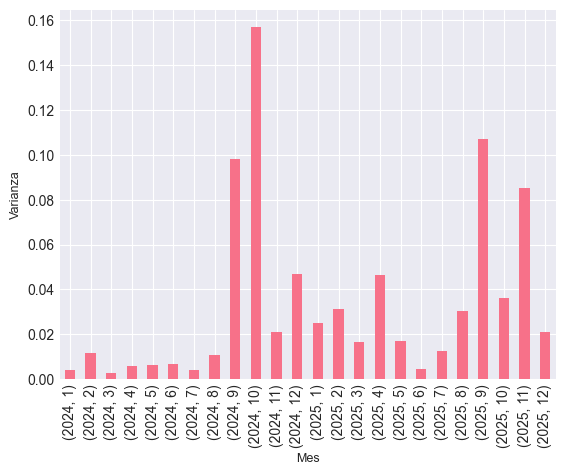

In [58]:
varianza_mes_anio = (promedio_magnitud.groupby(['Año', 'Mes'])['Magnitud'].var())

varianza_mes_anio.plot(kind='bar')
plt.xlabel('Mes', fontsize=9)
plt.ylabel('Varianza', fontsize=9)
plt.show()

# Análisis estadístico

In [59]:
# Estadísticas generales de magnitud
print("Estadísticas descriptivas de Magnitud:")
print(promedio_magnitud['Magnitud'].describe())

Estadísticas descriptivas de Magnitud:
count    731.000000
mean       3.190709
std        0.373194
min        1.973443
25%        3.051423
50%        3.297333
75%        3.464112
max        3.807692
Name: Magnitud, dtype: float64


In [60]:
promedio_magnitud.describe()

,Fecha,Magnitud,Mes,Año
count,731,731.000000,731.000000,731.000000
mean,2024-12-31 00:00:00,3.190709,6.519836,2024.499316
min,2024-01-01 00:00:00,1.973443,1.000000,2024.000000
25%,2024-07-01 12:00:00,3.051423,4.000000,2024.000000
50%,2024-12-31 00:00:00,3.297333,7.000000,2024.000000
75%,2025-07-01 12:00:00,3.464112,10.000000,2025.000000
max,2025-12-31 00:00:00,3.807692,12.000000,2025.000000
std,NaN,0.373194,3.451913,0.500342


## Medidas de tendencia central

In [61]:
media = np.mean(promedio_magnitud['Magnitud']) #media
print(promedio_magnitud['Magnitud'].round(1).mode())

0    3.5
Name: Magnitud, dtype: float64


## Medidas de dispersión

In [62]:
np.var(promedio_magnitud['Magnitud']) #varianza

np.float64(0.1390833770489978)

In [63]:
desv = np.std(promedio_magnitud['Magnitud']) #desviacion estandar
desv

np.float64(0.3729388382147907)

In [64]:
cv = (desv / media) * 100 #coeficiente de variacion
cv

np.float64(11.688274372382)

In [65]:
promedio_magnitud['Magnitud'].max() - promedio_magnitud['Magnitud'].min() #rango

np.float64(1.834249684741488)

## Gráfica de serie de tiempo original

In [66]:
#División de los datos por la fecha 
promedio_magnitud['Mes'] = promedio_magnitud['Fecha'].dt.month #extraemos el mes de la fecha
promedio_magnitud['Año'] = promedio_magnitud['Fecha'].dt.year #extraemos el año de la fecha
promedio_magnitud['Dia'] = promedio_magnitud['Fecha'].dt.day #extraemos el dia de la fecha
promedio_magnitud['Dia_semana'] = promedio_magnitud['Fecha'].dt.day_name() #extraemos el dia de la semana de la fecha

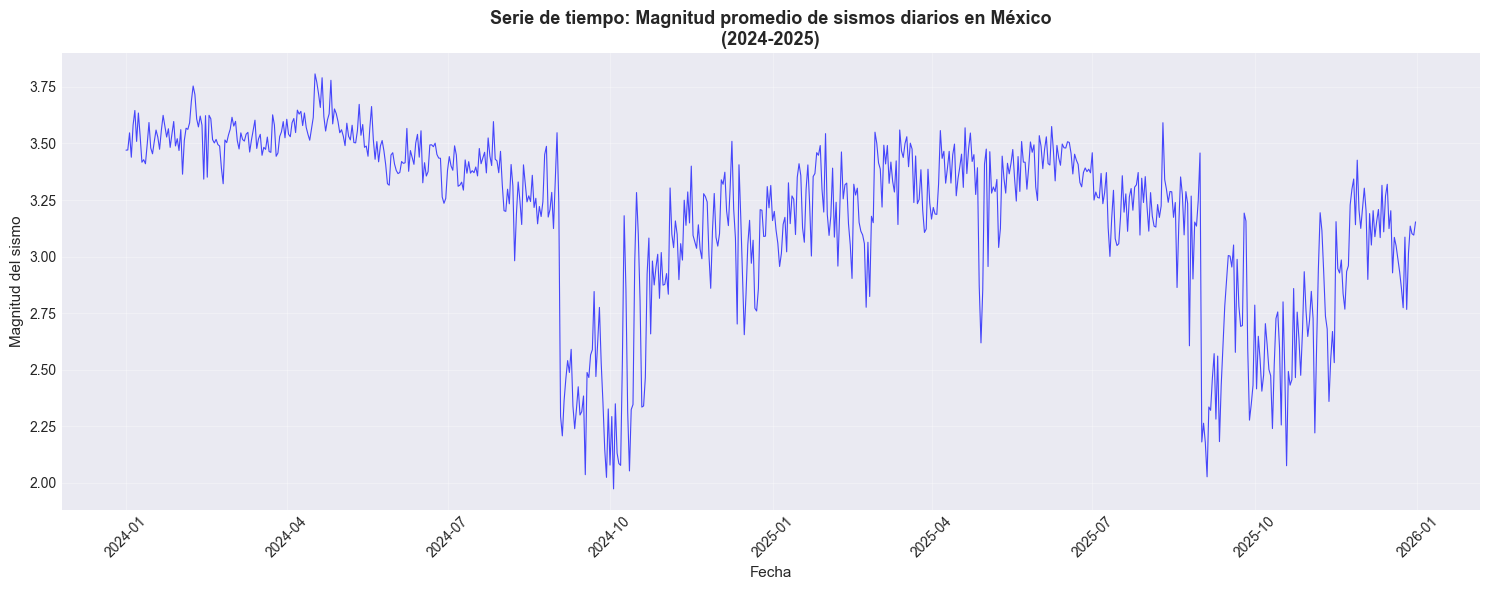

In [67]:
# 5. Visualización de la serie de tiempo original
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Gráfica de serie de tiempo original
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Magnitud'],
        linewidth=0.8, alpha=0.7, color='blue')
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Magnitud del sismo', fontsize=11)
ax.set_title('Serie de tiempo: Magnitud promedio de sismos diarios en México\n(2024-2025)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Transformación Logarítmica

Dado que el análisis ARCH detectó varianza condicional no constante (heterocedasticidad), se aplica la transformación logarítmica $Y_t = \\ln(X_t)$ para estabilizar la varianza. Esta transformación es especialmente útil en el periodo septiembre–noviembre, donde la serie original presenta alta volatilidad y valores extremos bajos (~2.0) que distorsionan la escala visual.

In [ ]:
# Transformación logarítmica para estabilizar la varianza
promedio_magnitud['Log_Magnitud'] = np.log(promedio_magnitud['Magnitud'])

# Comparación: serie original vs transformada
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Serie original
axes[0].plot(promedio_magnitud['Fecha'], promedio_magnitud['Magnitud'],
             linewidth=0.8, alpha=0.7, color='steelblue')
axes[0].set_ylabel('Magnitud original', fontsize=11)
axes[0].set_title('Serie Original: Magnitud promedio diaria', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Serie transformada
axes[1].plot(promedio_magnitud['Fecha'], promedio_magnitud['Log_Magnitud'],
             linewidth=0.8, alpha=0.7, color='darkorange')
axes[1].set_ylabel('ln(Magnitud)', fontsize=11)
axes[1].set_title('Serie Transformada: ln(Magnitud) — Estabilización de varianza', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fecha', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Comparación estadística: original vs transformada
print('Estadísticas descriptivas — Serie original:')
print(promedio_magnitud['Magnitud'].describe().round(4))
print()
print('Estadísticas descriptivas — ln(Magnitud):')
print(promedio_magnitud['Log_Magnitud'].describe().round(4))
print()
print(f"Varianza original : {promedio_magnitud['Magnitud'].var():.6f}")
print(f"Varianza log      : {promedio_magnitud['Log_Magnitud'].var():.6f}")
print(f"Reducción de varianza: {(1 - promedio_magnitud['Log_Magnitud'].var() / promedio_magnitud['Magnitud'].var())*100:.2f}%")

In [ ]:
# Zoom en el periodo crítico: septiembre–noviembre 2024
mask = (promedio_magnitud['Fecha'] >= '2024-09-01') & (promedio_magnitud['Fecha'] <= '2024-11-30')
df_zoom = promedio_magnitud[mask]

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(df_zoom['Fecha'], df_zoom['Magnitud'],
             linewidth=1, alpha=0.8, color='steelblue', label='Original')
axes[0].set_ylabel('Magnitud', fontsize=11)
axes[0].set_title('Periodo Sep–Nov 2024: Serie original', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df_zoom['Fecha'], df_zoom['Log_Magnitud'],
             linewidth=1, alpha=0.8, color='darkorange', label='ln(Magnitud)')
axes[1].set_ylabel('ln(Magnitud)', fontsize=11)
axes[1].set_title('Periodo Sep–Nov 2024: Serie transformada ln(Magnitud)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fecha', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

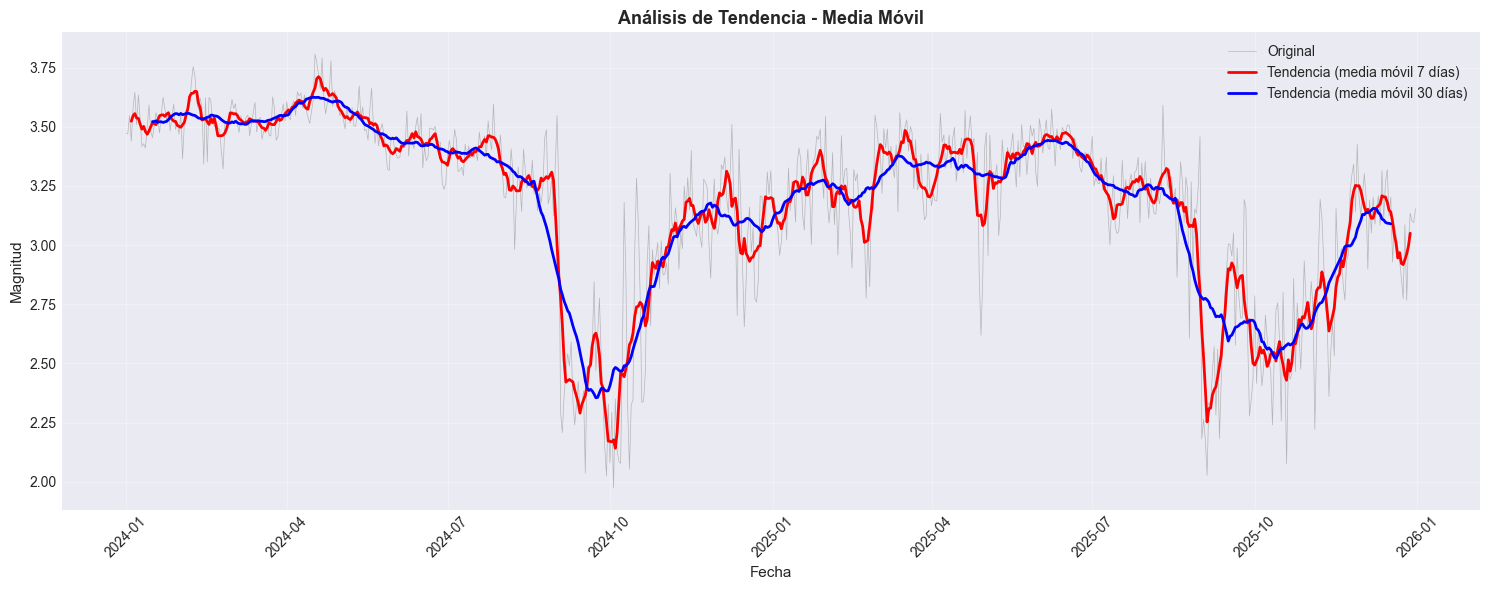

In [68]:
# 6. Análisis de tendencia

# Calcular tendencia usando media móvil
promedio_magnitud['Tendencia_MA7'] = promedio_magnitud['Magnitud'].rolling(window=7, center=True).mean()
promedio_magnitud['Tendencia_MA30'] = promedio_magnitud['Magnitud'].rolling(window=30, center=True).mean()

# Visualizar tendencia
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Magnitud'],
        linewidth=0.5, alpha=0.5, color='gray', label='Original')
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Tendencia_MA7'], #se crea nueva columna
        linewidth=2, color='red', label='Tendencia (media móvil 7 días)')
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Tendencia_MA30'], # se crea nueva columna
        linewidth=2, color='blue', label='Tendencia (media móvil 30 días)')
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Magnitud', fontsize=11)
ax.set_title('Análisis de Tendencia - Media Móvil', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

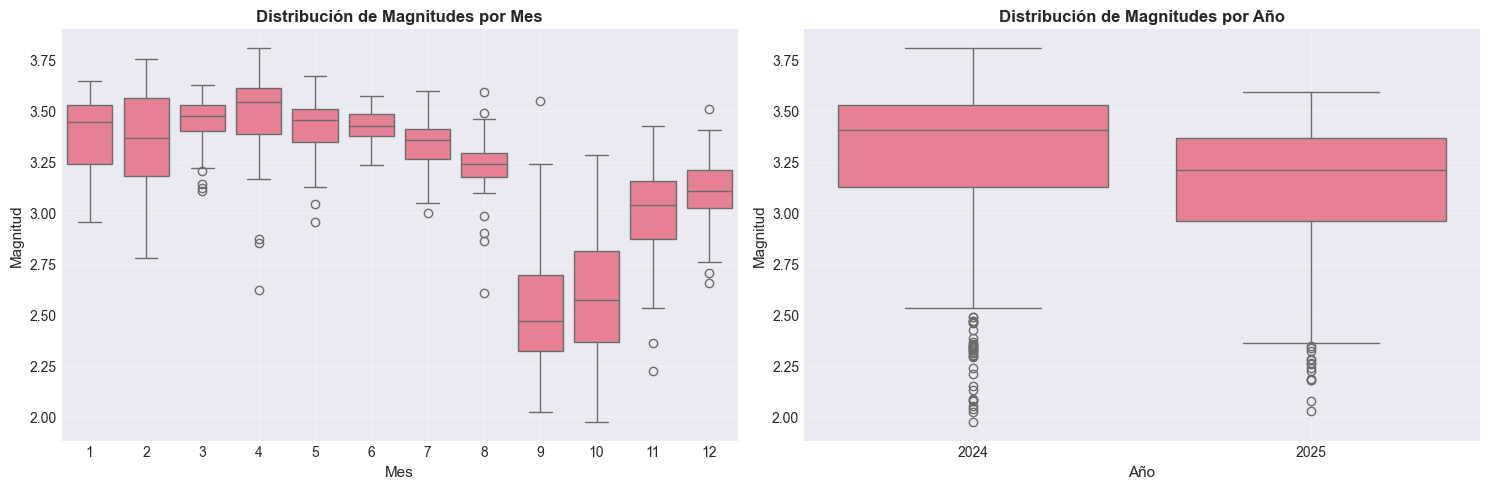

Estadísticas por mes:
      mean    std    min    max  count
Mes                                   
1    3.379  0.187  2.956  3.646     62
2    3.355  0.237  2.776  3.754     57
3    3.445  0.126  3.107  3.627     62
4    3.473  0.223  2.619  3.808     60
5    3.427  0.133  2.956  3.673     62
6    3.428  0.075  3.236  3.575     60
7    3.325  0.124  3.001  3.597     62
8    3.229  0.146  2.606  3.592     62
9    2.535  0.323  2.024  3.548     60
10   2.592  0.309  1.973  3.283     62
11   3.002  0.249  2.221  3.426     60
12   3.102  0.183  2.655  3.510     62


In [69]:
#7. Análisis de estacionalidad

# Boxplot por mes para ver estacionalidad
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot por mes (todos los datos)
sns.boxplot(data=promedio_magnitud, x='Mes', y='Magnitud', ax=axes[0])
axes[0].set_xlabel('Mes', fontsize=11)
axes[0].set_ylabel('Magnitud', fontsize=11)
axes[0].set_title('Distribución de Magnitudes por Mes', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Boxplot por año
sns.boxplot(data=promedio_magnitud, x='Año', y='Magnitud', ax=axes[1])
axes[1].set_xlabel('Año', fontsize=11)
axes[1].set_ylabel('Magnitud', fontsize=11)
axes[1].set_title('Distribución de Magnitudes por Año', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas por mes
estadisticas_mes = promedio_magnitud.groupby('Mes')['Magnitud'].agg(['mean', 'std', 'min', 'max', 'count'])
print("Estadísticas por mes:")
print(estadisticas_mes.round(3))

# Análisis de los componentes

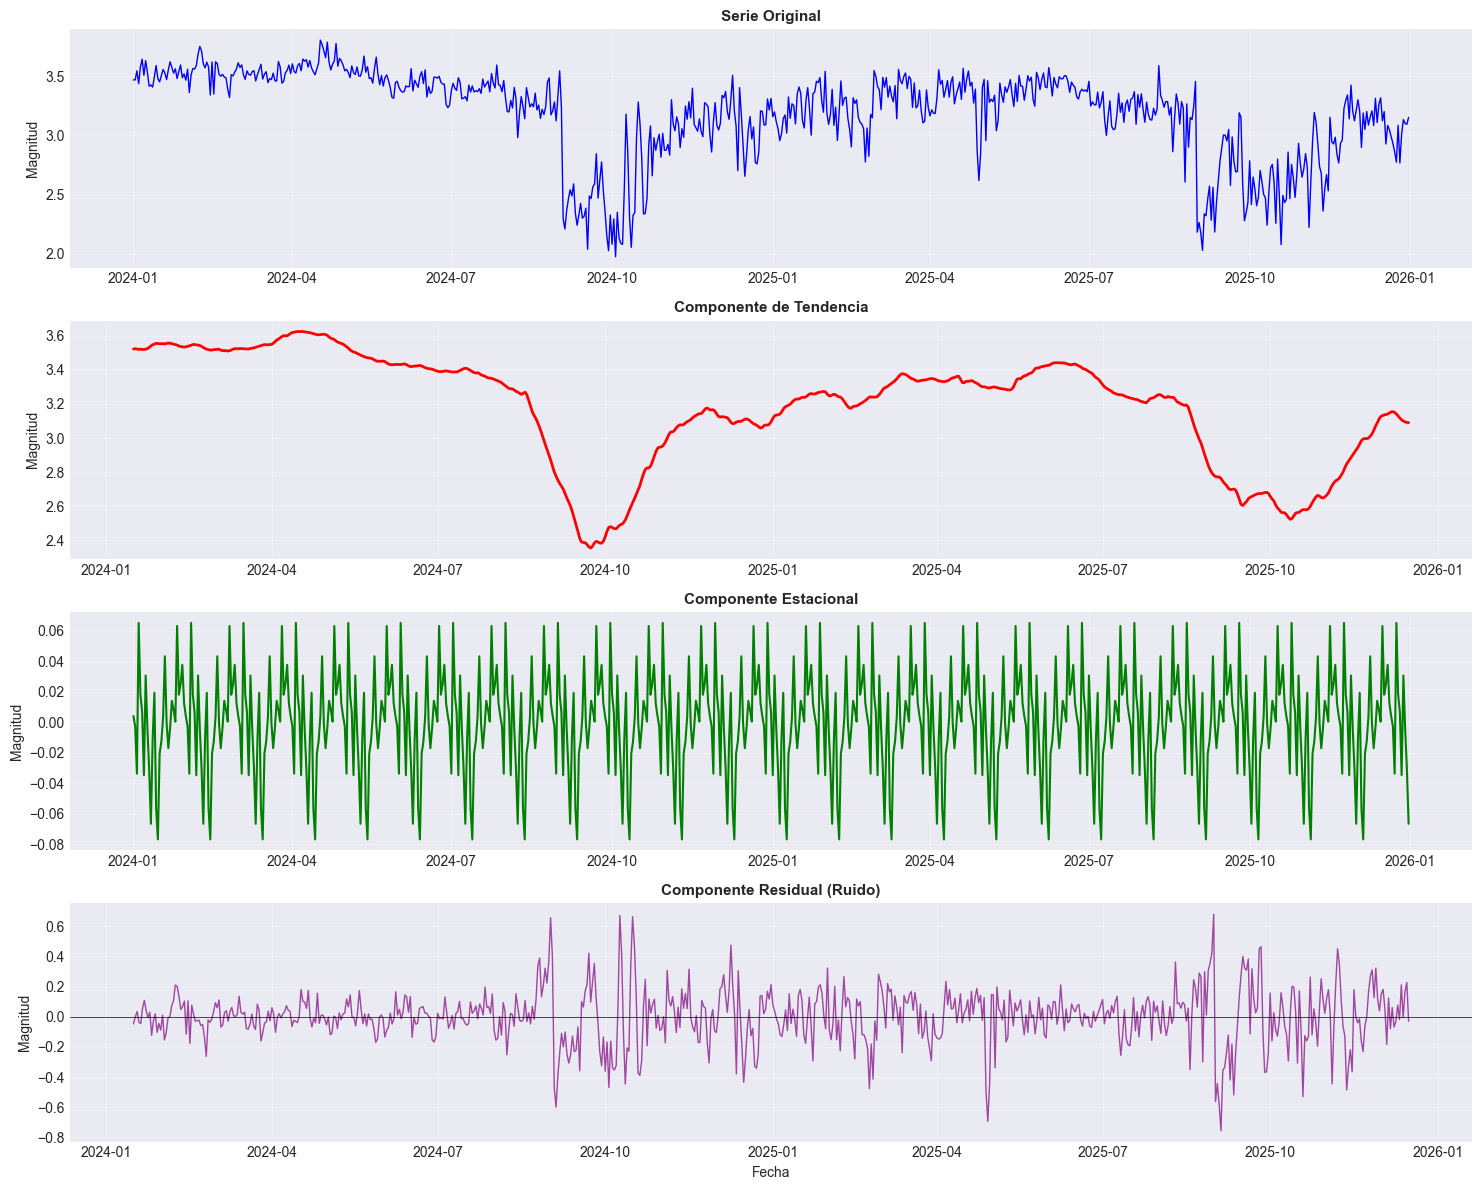

In [70]:
#frecuencia diaria
# Usamos la serie transformada logarítmicamente para la descomposición
sismos_ts = promedio_magnitud.set_index('Fecha')['Log_Magnitud'].sort_index()

#fechas completas
fechas_completas = pd.date_range(start=sismos_ts.index.min(), end=sismos_ts.index.max(), freq='D')
sismos_ts = sismos_ts.reindex(fechas_completas)

#Interpolacion de valores faltantes (si existen)
if sismos_ts.isnull().any():
    sismos_ts = sismos_ts.interpolate(method='linear')
    print(f"Se interpolaron {sismos_ts.isnull().sum()} valores faltantes")

#Descomposicion
descomposicion = seasonal_decompose(sismos_ts, model='additive', period=30)  # period=30 para estacionalidad mensual
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12))

# Original
ax1.plot(sismos_ts.index, sismos_ts, color='blue', linewidth=1)
ax1.set_title('Serie Transformada ln(Magnitud)', fontsize=11, fontweight='bold')
ax1.set_ylabel('ln(Magnitud)')
ax1.grid(True, alpha=0.3)

# Tendencia
ax2.plot(descomposicion.trend.index, descomposicion.trend, color='red', linewidth=2)
ax2.set_title('Componente de Tendencia', fontsize=11, fontweight='bold')
ax2.set_ylabel('Magnitud')
ax2.grid(True, alpha=0.3)

# Estacionalidad
ax3.plot(descomposicion.seasonal.index, descomposicion.seasonal, color='green', linewidth=1.5)
ax3.set_title('Componente Estacional', fontsize=11, fontweight='bold')
ax3.set_ylabel('Magnitud')
ax3.grid(True, alpha=0.3)

# Residuos
ax4.plot(descomposicion.resid.index, descomposicion.resid, color='purple', linewidth=1, alpha=0.7)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax4.set_title('Componente Residual (Ruido)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Magnitud')
ax4.set_xlabel('Fecha')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [71]:
# Análisis estadístico de los componentes

print("Estadísticas de los componentes de descomposición:")
print("\nComponente de Tendencia:")
print(descomposicion.trend.describe())
print("\nComponente Estacional:")
print(descomposicion.seasonal.describe())
print("\nComponente Residual:")
print(descomposicion.resid.describe())

# Varianza explicada por cada componente
varianza_total = np.var(sismos_ts.dropna())
varianza_tendencia = np.var(descomposicion.trend.dropna())
varianza_estacional = np.var(descomposicion.seasonal.dropna())
varianza_residual = np.var(descomposicion.resid.dropna())

print("\n--- Varianza explicada por cada componente ---")
print(f"Varianza total: {varianza_total:.4f}")
print(f"Varianza tendencia: {varianza_tendencia:.4f} ({varianza_tendencia/varianza_total*100:.2f}%)")
print(f"Varianza estacional: {varianza_estacional:.4f} ({varianza_estacional/varianza_total*100:.2f}%)")
print(f"Varianza residual: {varianza_residual:.4f} ({varianza_residual/varianza_total*100:.2f}%)")

Estadísticas de los componentes de descomposición:

Componente de Tendencia:
count    701.000000
mean       3.186613
std        0.320381
min        2.355352
25%        3.060341
50%        3.260649
75%        3.421640
max        3.624818
Name: trend, dtype: float64

Componente Estacional:
count    731.000000
mean      -0.000064
std        0.032940
min       -0.076803
25%       -0.016946
50%        0.000457
75%        0.018353
max        0.065234
Name: seasonal, dtype: float64

Componente Residual:
count    701.000000
mean       0.000975
std        0.178568
min       -0.756151
25%       -0.082806
50%        0.011271
75%        0.098075
max        0.679210
Name: resid, dtype: float64

--- Varianza explicada por cada componente ---
Varianza total: 0.1391
Varianza tendencia: 0.1025 (73.70%)
Varianza estacional: 0.0011 (0.78%)
Varianza residual: 0.0318 (22.89%)


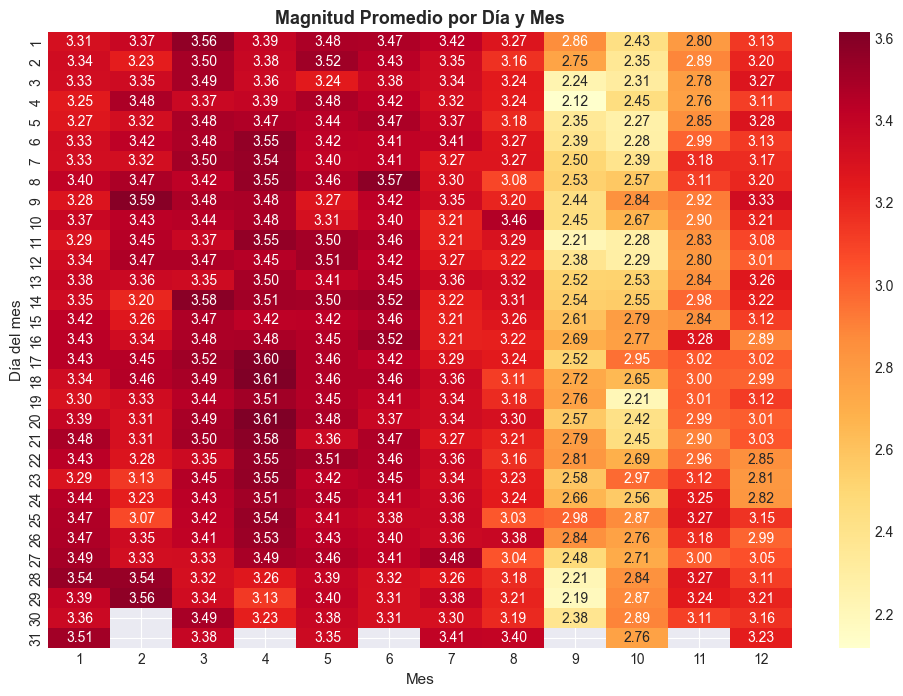

In [72]:
# Heatmap de magnitudes promedio por mes y día
pivot_magnitud = promedio_magnitud.pivot_table(
    values='Magnitud',
    index=promedio_magnitud['Fecha'].dt.day,
    columns=promedio_magnitud['Fecha'].dt.month,
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_magnitud, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Día del mes', fontsize=11)
ax.set_title('Magnitud Promedio por Día y Mes', fontsize=13, fontweight='bold')
plt.show()

## Análisis de  Autocorrelación

### ACF

In [73]:
serie = promedio_magnitud['Magnitud']

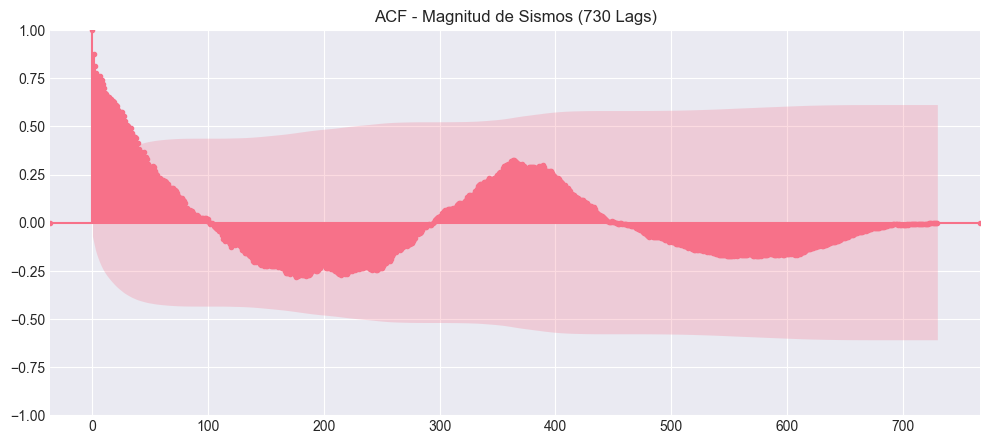

In [74]:
fig, ax = plt.subplots(figsize=(12, 5))
# vlines=False quita las líneas verticales densas
plot_acf(serie, lags=730, ax=ax, marker='o', markersize=3)
ax.set_title('ACF - Magnitud de Sismos (730 Lags)')
plt.show()

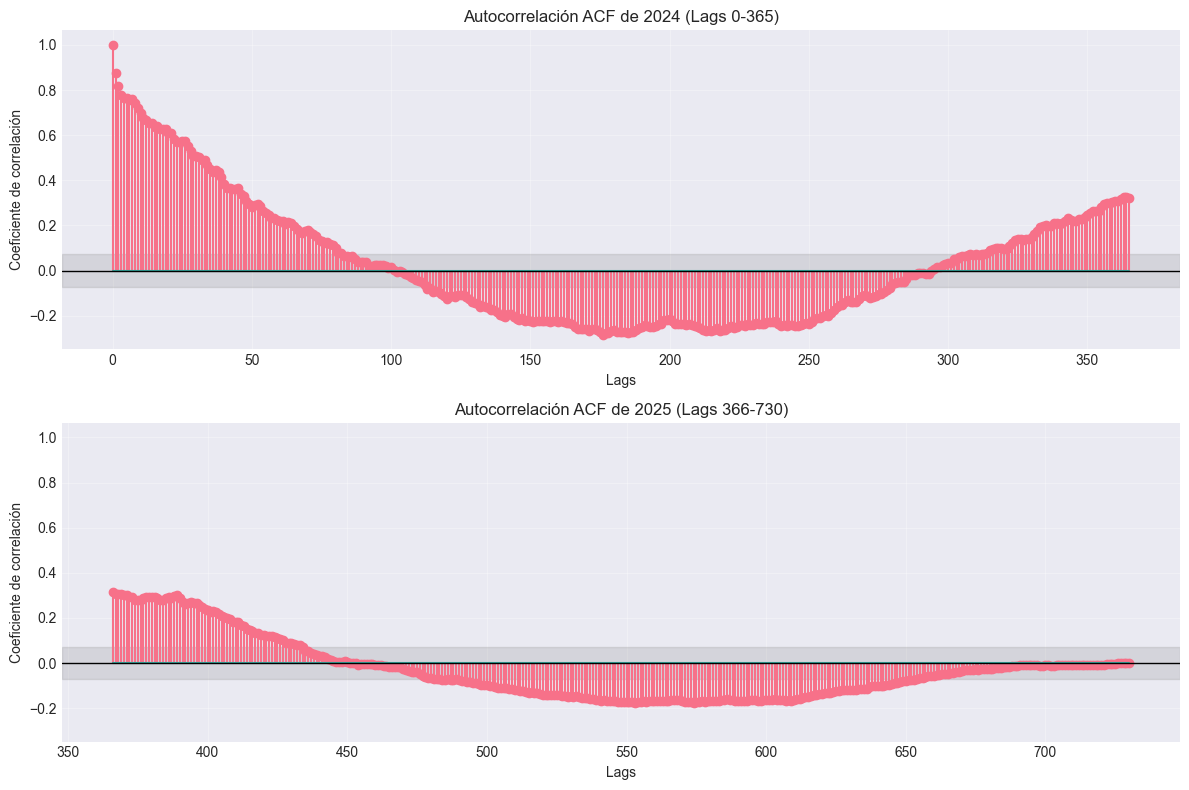

In [75]:
valores_acf = acf(serie, nlags=730)
n = len(serie)
banda = 1.96 / np.sqrt(n)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharey=True)
banda = 1.96 / np.sqrt(n)

ax1.stem(range(366), valores_acf[:366]) #366 lags para 2024
ax1.axhspan(-banda, banda, alpha=0.2, color='gray', label='Banda de confianza (95%)')
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title("Autocorrelación ACF de 2024 (Lags 0-365)")
ax1.set_xlabel('Lags')
ax1.set_ylabel('Coeficiente de correlación')
ax1.grid(True, alpha=0.3)

ax2.stem(range(366, 731), valores_acf[366:]) #365 lags para 2025
ax2.axhspan(-banda, banda, alpha=0.2, color='gray')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title("Autocorrelación ACF de 2025 (Lags 366-730)")
ax2.set_xlabel('Lags')
ax2.set_ylabel('Coeficiente de correlación')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Correlograma de Calor

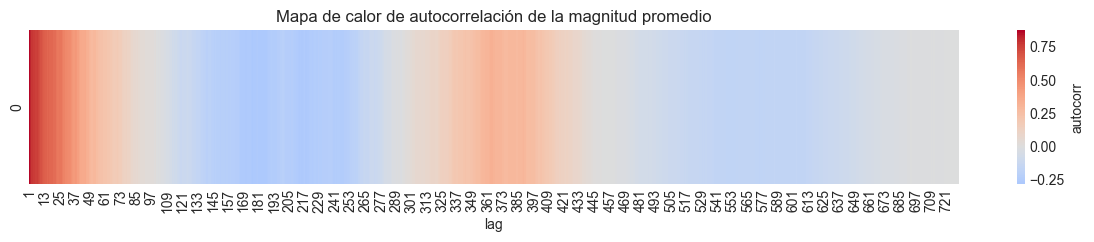

In [76]:
lags = 730
acf_values = acf(serie, nlags= lags)
df_acf = pd.DataFrame(acf_values[1:].reshape(1, -1), 
                      columns=range(1, lags + 1))

plt.figure(figsize=(15, 2))
sns.heatmap(df_acf, annot=False, cmap='coolwarm', center=0,      
            cbar_kws={'label': 'autocorr'})

plt.title('Mapa de calor de autocorrelación de la magnitud promedio')
plt.xlabel('lag')
plt.show()

Después del lag 0 la mayoría los valores se encuentran dentro del intervalo de confianza, por lo que las correlaciones no son estadísticamente significativas. Se observa que puede haberr correlación en el lag 50, entre 241 y 253.

### PACF

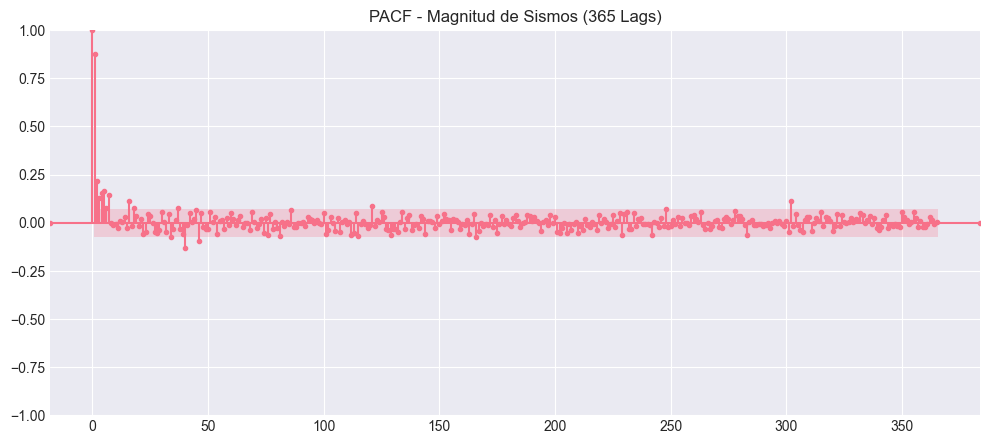

In [77]:
fig, ax = plt.subplots(figsize=(12, 5))
# vlines=False quita las líneas verticales densas
plot_pacf(serie, lags=365, ax=ax, marker='o', markersize=3)
ax.set_title('PACF - Magnitud de Sismos (365 Lags)')
plt.show()

# PRUEBAS ESTADÍSTICAS

# BLOQUE B

## Inspección visual de la serie

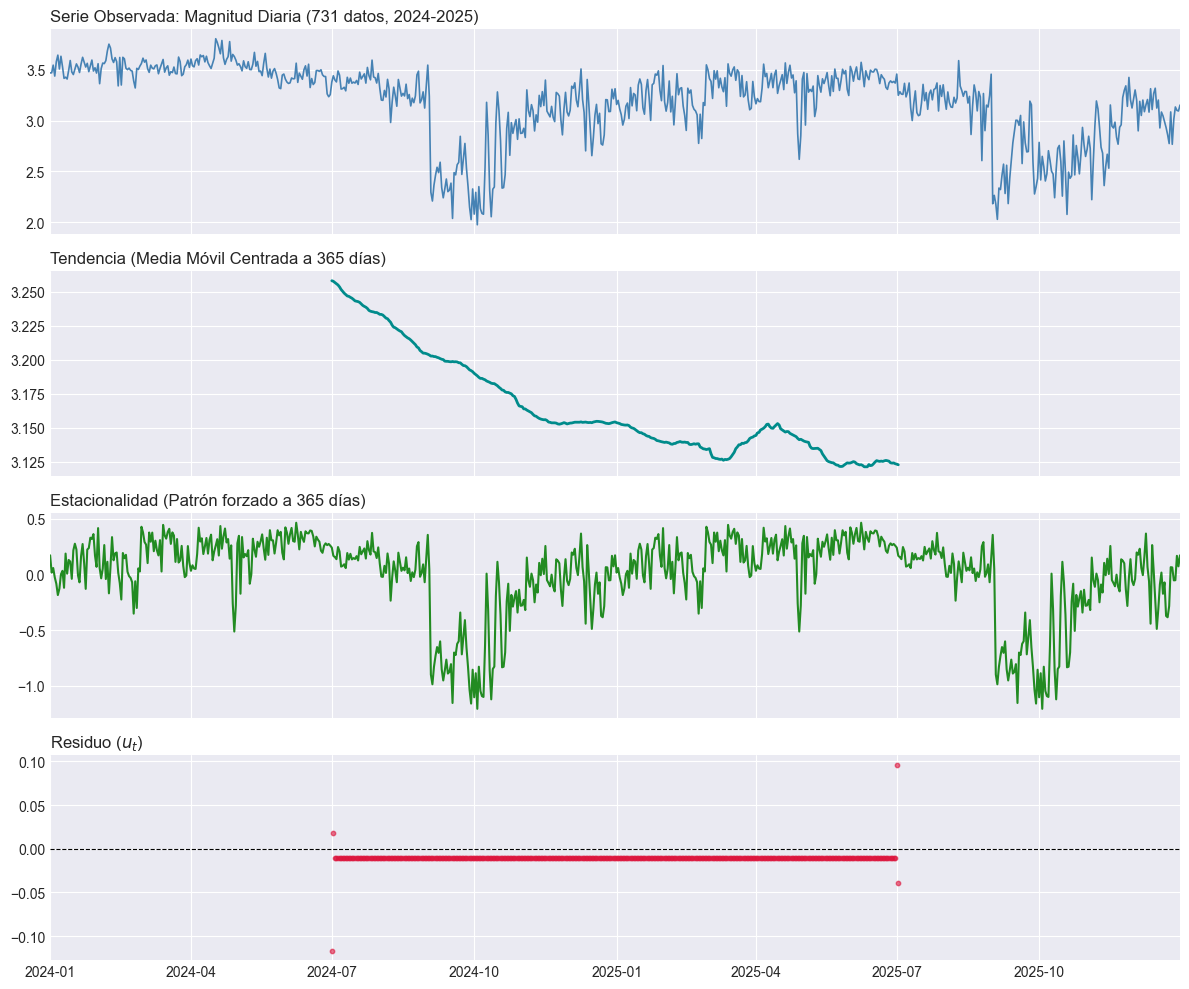

In [78]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Definicion de fechas
fechas_exactas = pd.date_range(start='2024-01-01', end='2025-12-31', freq='D')

sismos_ts = promedio_magnitud.set_index('Fecha')['Magnitud']

sismos_ts = sismos_ts.reindex(fechas_exactas)
ts = sismos_ts.interpolate(method='linear')
ts.name = "Magnitud"

# Desomposición para 365 dias
descomposicion = seasonal_decompose(ts, model='additive', period=365)

colores = {
    'observed': 'steelblue',
    'trend': 'darkcyan',
    'seasonal': 'forestgreen',
    'resid': 'crimson'
}

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].set_xlim([fechas_exactas.min(), fechas_exactas.max()])

# Componente Observado
axes[0].plot(ts.index, ts, color=colores['observed'], lw=1.2)
axes[0].set_title('Serie Observada: Magnitud Diaria (731 datos, 2024-2025)', loc='left', fontsize=12)

# Componente Tendencia
axes[1].plot(descomposicion.trend.index, descomposicion.trend, color=colores['trend'], lw=2)
axes[1].set_title('Tendencia (Media Móvil Centrada a 365 días)', loc='left', fontsize=12)

# Componente Estacional
axes[2].plot(descomposicion.seasonal.index, descomposicion.seasonal, color=colores['seasonal'], lw=1.5)
axes[2].set_title('Estacionalidad (Patrón forzado a 365 días)', loc='left', fontsize=12)

# Componente Residuo
axes[3].scatter(descomposicion.resid.index, descomposicion.resid, color=colores['resid'], s=10, alpha=0.6)
axes[3].axhline(0, color='black', lw=0.8, ls='--')
axes[3].set_title('Residuo ($u_t$)', loc='left', fontsize=12)

plt.tight_layout()
plt.show()

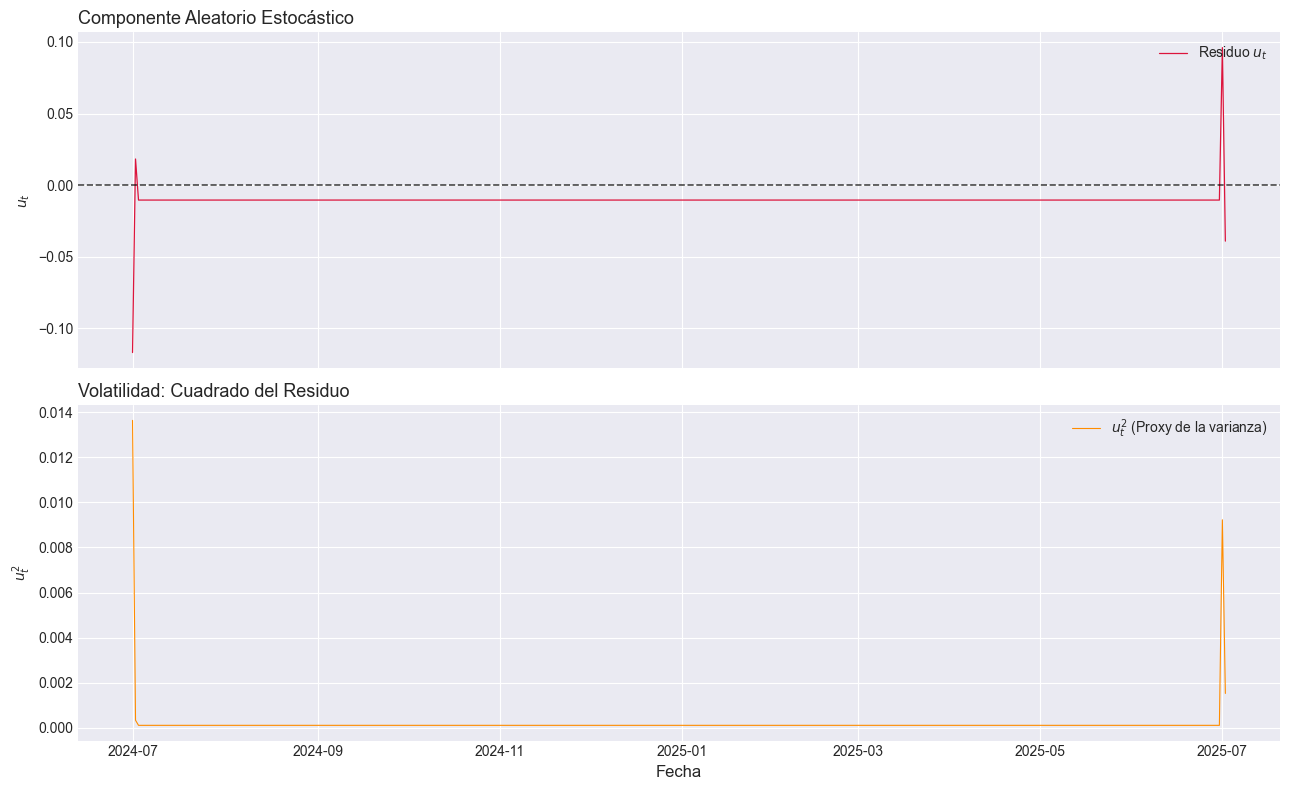

In [79]:
residuo_puro = descomposicion.resid.dropna()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Panel 1: Residuo en nivel (u_t)
axes[0].plot(residuo_puro.index, residuo_puro, color='crimson', linewidth=0.9, label='Residuo $u_t$')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].set_title('Componente Aleatorio Estocástico', loc='left', fontsize=13)
axes[0].set_ylabel('$u_t$')
axes[0].legend(loc='upper right')

# Panel 2: Residuo al cuadrado (u_t^2) - Inspección de Volatilidad
axes[1].plot(residuo_puro.index, residuo_puro**2, color='darkorange', linewidth=0.8,
             label='$u_t^2$ (Proxy de la varianza)')
axes[1].set_title('Volatilidad: Cuadrado del Residuo', loc='left', fontsize=13)
axes[1].set_ylabel('$u_t^2$')
axes[1].set_xlabel('Fecha', fontsize=12)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## Estadisticas moviles

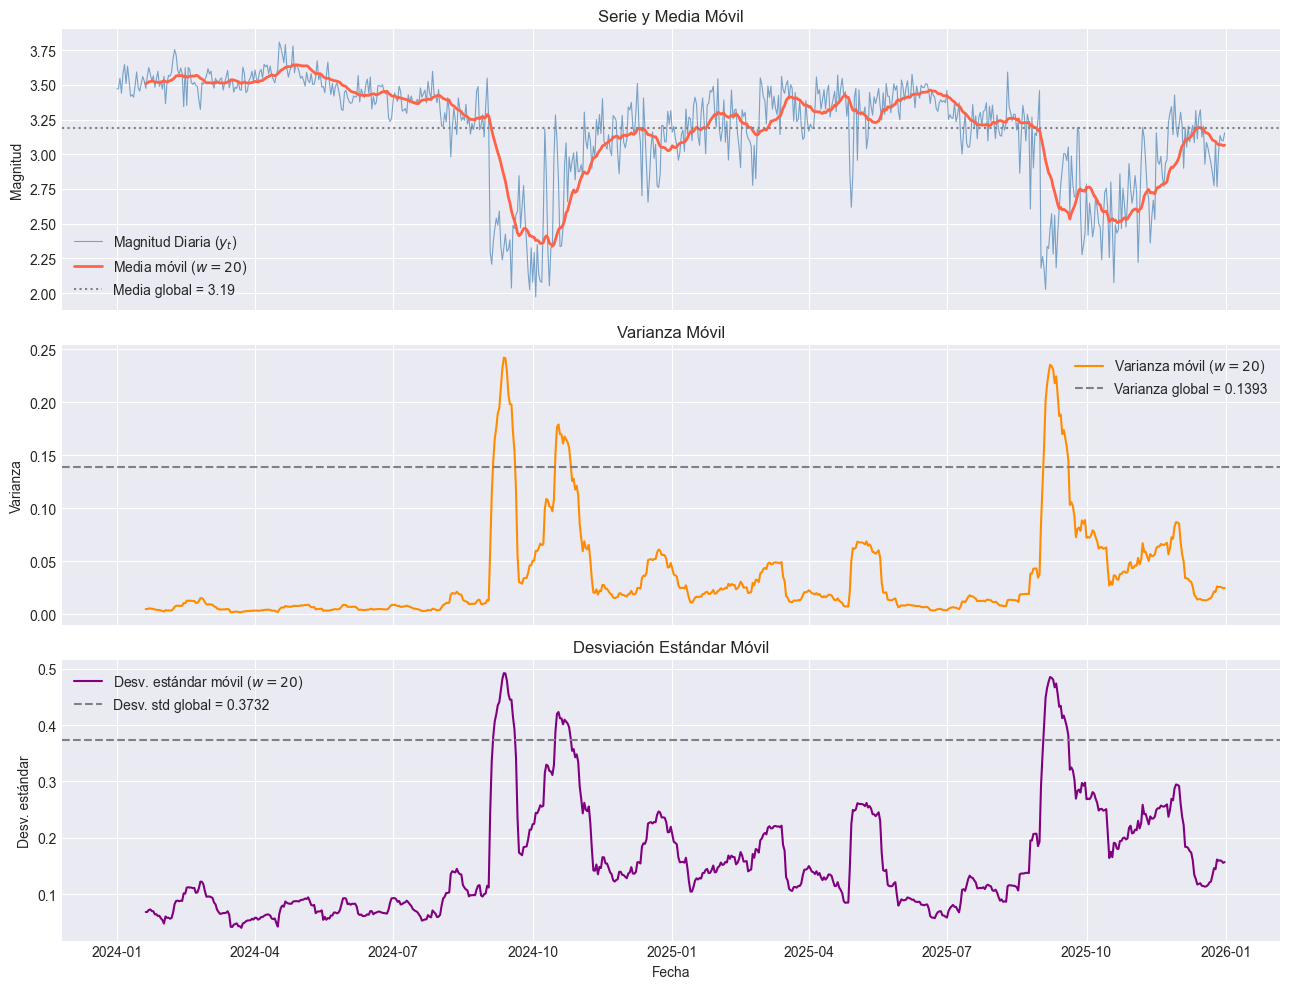

Test de Levene: igualdad de varianza incondicional entre mitades (2024 vs 2025)
 W = 1.7855  |  p-valor = 0.1819
No se rechaza homogeneidad incondicional (p >= 0.05)


In [80]:
import scipy.stats as stats

# Parámetro de la ventana (20 días de agrupamiento)
window = 20
rolling_mean = ts.rolling(window).mean()
rolling_std  = ts.rolling(window).std()
rolling_var  = ts.rolling(window).var()

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Panel 1: Serie observada y Media Móvil
axes[0].plot(ts.index, ts, color='steelblue', linewidth=0.8, alpha=0.7, label='Magnitud Diaria ($y_t$)')
axes[0].plot(rolling_mean.index, rolling_mean, color='tomato', linewidth=2,
             label=f'Media móvil ($w={window}$)')
# Línea base ajustada a la media de la magnitud (en lugar de 0)
axes[0].axhline(ts.mean(), color='gray', linestyle=':', linewidth=1.5, label=f'Media global = {ts.mean():.2f}')
axes[0].set_title('Serie y Media Móvil', fontsize=12)
axes[0].set_ylabel('Magnitud')
axes[0].legend()

# Panel 2: Varianza Móvil
axes[1].plot(rolling_var.index, rolling_var, color='darkorange', linewidth=1.5,
             label=f'Varianza móvil ($w={window}$)')
axes[1].axhline(ts.var(), color='gray', linestyle='--', linewidth=1.5,
                label=f'Varianza global = {ts.var():.4f}')
axes[1].set_title('Varianza Móvil', fontsize=12)
axes[1].set_ylabel('Varianza')
axes[1].legend()

# Panel 3: Desviación Estándar Móvil
axes[2].plot(rolling_std.index, rolling_std, color='purple', linewidth=1.5,
             label=f'Desv. estándar móvil ($w={window}$)')
axes[2].axhline(ts.std(), color='gray', linestyle='--', linewidth=1.5,
                label=f'Desv. std global = {ts.std():.4f}')
axes[2].set_title('Desviación Estándar Móvil', fontsize=12)
axes[2].set_ylabel('Desv. estándar')
axes[2].set_xlabel('Fecha')
axes[2].legend()

plt.tight_layout()
plt.show()

# Test de Levene
n_obs = len(ts)
mid = n_obs // 2

stat_lev, p_lev = stats.levene(ts.iloc[:mid].dropna(), ts.iloc[mid:].dropna())

print("Test de Levene: igualdad de varianza incondicional entre mitades (2024 vs 2025)")
print(f" W = {stat_lev:.4f}  |  p-valor = {p_lev:.4f}")
print(f"{'Evidencia de heterocedasticidad INCONDICIONAL (p < 0.05)' if p_lev < 0.05 else 'No se rechaza homogeneidad incondicional (p >= 0.05)'}")

## Prueba de raiz unitaria

Número máximo de rezagos evaluados (Regla de Schwert): 19

ADF Sin constante (n)
Estadístico ADF    : -0.5274
p-valor            : 0.4848
Rezagos usados     : 6
Valores críticos   : 1%: -2.569  5%: -1.941  10%: -1.616
  Conclusión (5%)    : No se rechaza H0: Posible RAÍZ UNITARIA (No estacionaria)

ADF Con constante (c)
Estadístico ADF    : -2.6321
p-valor            : 0.0865
Rezagos usados     : 6
Valores críticos   : 1%: -3.439  5%: -2.866  10%: -2.569
  Conclusión (5%)    : No se rechaza H0: Posible RAÍZ UNITARIA (No estacionaria)



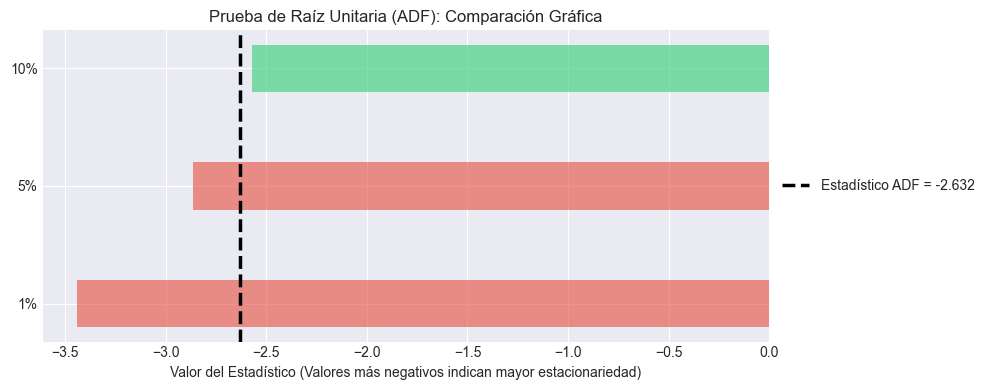

In [81]:
p_max = int(12 * (n_obs / 100) ** 0.25)   
print(f"Número máximo de rezagos evaluados (Regla de Schwert): {p_max}\n")

# Se asume que la serie fluctúa en torno al cero
adf_n = adfuller(ts, maxlag=p_max, autolag='aic', regression='n')

adf_c = adfuller(ts, maxlag=p_max, autolag='aic', regression='c')

for label, res in [("Sin constante (n)", adf_n), ("Con constante (c)", adf_c)]:
    print(f"ADF {label}")
    print(f"Estadístico ADF    : {res[0]:.4f}")
    print(f"p-valor            : {res[1]:.4f}")
    print(f"Rezagos usados     : {res[2]}")
    print(f"Valores críticos   : " + "  ".join([f"{k}: {v:.3f}" for k, v in res[4].items()]))
    concl = "Se rechaza H0: La serie ES ESTACIONARIA" if res[1] < 0.05 else "No se rechaza H0: Posible RAÍZ UNITARIA (No estacionaria)"
    print(f"  Conclusión (5%)    : {concl}\n")


fig, ax = plt.subplots(figsize=(10, 4))
criticos = adf_c[4]
niveles  = list(criticos.keys())
valores  = list(criticos.values())

colores  = ['#2ecc71' if adf_c[0] < v else '#e74c3c' for v in valores]

ax.barh(niveles, valores, color=colores, alpha=0.6, height=0.4)
ax.axvline(adf_c[0], color='black', linewidth=2.5, linestyle='--',
           label=f'Estadístico ADF = {adf_c[0]:.3f}')

ax.set_xlabel('Valor del Estadístico (Valores más negativos indican mayor estacionariedad)')
ax.set_title('Prueba de Raíz Unitaria (ADF): Comparación Gráfica')
# Ajustar la leyenda para que no tape las barras
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## ACF

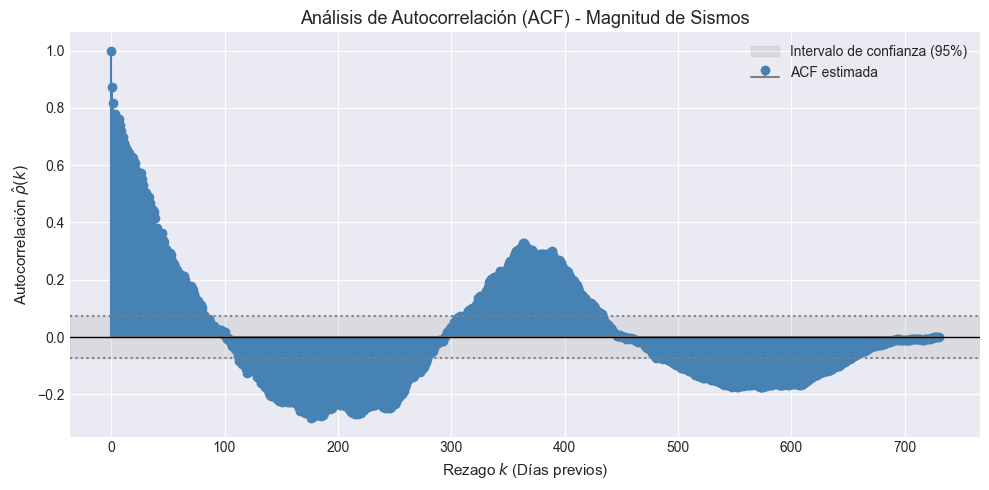

Resumen Estadístico de la ACF sobre la Magnitud:
--------------------------------------------------
Observaciones (n)             : 731
Frontera de significancia (95%): ± 0.0725
Rezagos significativos : 542 de 730
Conclusión:Existen algunos días pasados con correlación débil.


In [82]:
ts_clean = ts.dropna()
n_obs = len(ts_clean)
lags_max = 730

banda = 1.96 / np.sqrt(n_obs)

# Calculamos la Autocorrelación
acf_vals = acf(ts_clean, nlags=lags_max, fft=True)

fig, ax = plt.subplots(figsize=(10, 5))

k_vals = np.arange(0, lags_max + 1)
ax.stem(k_vals, acf_vals, linefmt='steelblue', markerfmt='o', basefmt='gray', label='ACF estimada')

ax.axhspan(-banda, banda, alpha=0.15, color='gray', label='Intervalo de confianza (95%)')
ax.axhline(banda, color='gray', linestyle=':', linewidth=1.5)
ax.axhline(-banda, color='gray', linestyle=':', linewidth=1.5)
ax.axhline(0, color='black', linewidth=1)

ax.set_title('Análisis de Autocorrelación (ACF) - Magnitud de Sismos', fontsize=13)
ax.set_xlabel('Rezago $k$ (Días previos)', fontsize=11)
ax.set_ylabel(r'Autocorrelación $\hat{\rho}(k)$', fontsize=11)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


print("Resumen Estadístico de la ACF sobre la Magnitud:")
print("-" * 50)
print(f"Observaciones (n)             : {n_obs}")
print(f"Frontera de significancia (95%): ± {banda:.4f}")

rezagos_significativos = sum(abs(acf_vals[1:]) > banda)
print(f"Rezagos significativos : {rezagos_significativos} de {lags_max}")

if rezagos_significativos == 0:
    print("Conclusión:La serie se comporta como Ruido Blanco estricto (0 autocorrelación).")
else:
    print("Conclusión:Existen algunos días pasados con correlación débil.")

## PACF

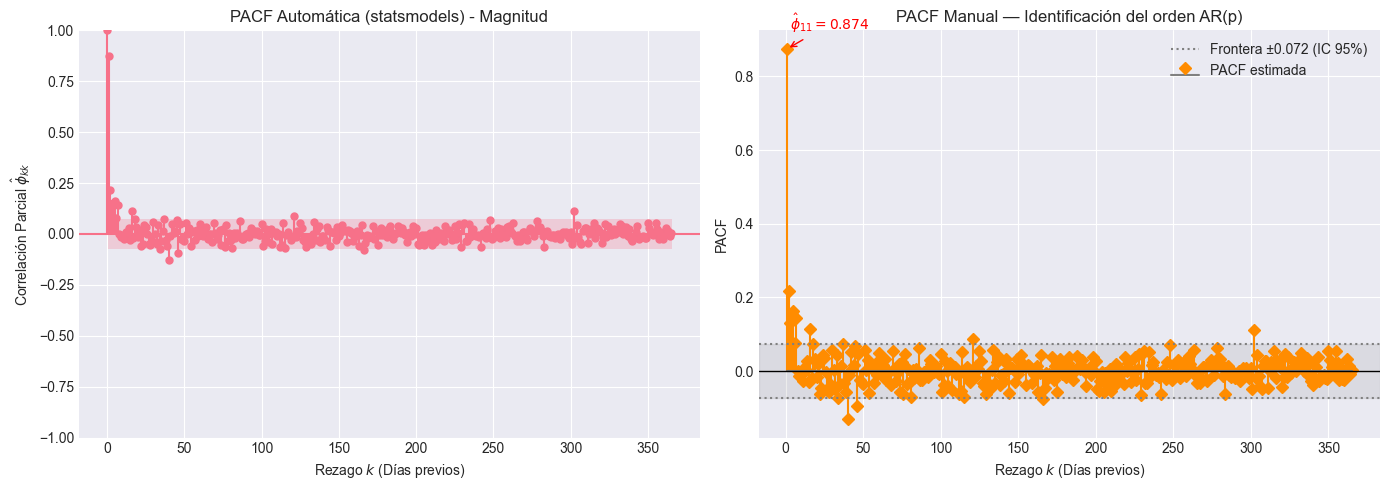

Análisis de Identificación del Modelo Auto-Regresivo (AR):
------------------------------------------------------------
PACF en rezago 1 (estimado)   : 0.8745
Rezagos significativos: [1, 2, 3, 4, 5, 6, 7, 16, 18, 37, 40, 46, 121, 166, 302]
Orden AR(p) sugerido: p = 302 (Modelo Auto-Regresivo)


In [93]:
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf

ts_clean = ts.dropna()
n_obs = len(ts_clean)
lags_max = 365
banda = 1.96 / np.sqrt(n_obs)

# Método YWM
pacf_vals = pacf(ts_clean, nlags=lags_max, method='ywm')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Gráfica automática de statsmodels
plot_pacf(ts_clean, lags=lags_max, ax=axes[0], method='ywm',
          title='PACF Automática (statsmodels) - Magnitud')
axes[0].set_xlabel('Rezago $k$ (Días previos)')
axes[0].set_ylabel('Correlación Parcial $\\hat{\\phi}_{kk}$')

# Panel 2: Gráfica manual con análisis detallado
k_vals = np.arange(1, lags_max + 1)
axes[1].stem(k_vals, pacf_vals[1:], linefmt='darkorange', markerfmt='D',
             basefmt='gray', label='PACF estimada')

# Bandas de confianza e indicador de cero
axes[1].axhspan(-banda, banda, alpha=0.15, color='gray')
axes[1].axhline( banda, color='gray', linestyle=':', linewidth=1.5,
                label=f'Frontera ±{banda:.3f} (IC 95%)')
axes[1].axhline(-banda, color='gray', linestyle=':', linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=1)

# Anotación dinámica para el rezago 1 (ajustada para no salirse de la gráfica)
offset_y = 0.05 if pacf_vals[1] >= 0 else -0.05
axes[1].annotate(
    f'$\\hat{{\\phi}}_{{11}} = {pacf_vals[1]:.3f}$',
    xy=(1, pacf_vals[1]), xytext=(3, pacf_vals[1] + offset_y),
    arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')

axes[1].set_title('PACF Manual — Identificación del orden AR(p)')
axes[1].set_xlabel('Rezago $k$ (Días previos)')
axes[1].set_ylabel('PACF')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("Análisis de Identificación del Modelo Auto-Regresivo (AR):")
print("-" * 60)
print(f"PACF en rezago 1 (estimado)   : {pacf_vals[1]:.4f}")

# Extraemos todos los rezagos que superan la banda (ignorando el rezago 0)
sig_pacf = [k for k in range(1, lags_max + 1) if abs(pacf_vals[k]) > banda]

print(f"Rezagos significativos: {sig_pacf if sig_pacf else 'Ninguno'}")

# Lógica para sugerir el modelo
if not sig_pacf:
    print("Orden AR(p) sugerido: p = 0 (Ruido Blanco en la media)")
elif sig_pacf[0] == 1:
    print(f"Orden AR(p) sugerido: p = {max(sig_pacf)} (Modelo Auto-Regresivo)")
else:
    print("Orden AR(p) sugerido: p = 0 (Los picos lejanos son probablemente espurios/ruido estadístico)")

## Prueba de Ljung-Box

Prueba de Ljung-Box sobre la Magnitud Diaria (y_t)
  Rezago h   Estadístico Q         p-valor           Conclusión
-----------------------------------------------------------------
         5       2354.1431        0.000000 Rechaza H0 (Hay autocorrelación)
         6       2774.8909        0.000000 Rechaza H0 (Hay autocorrelación)
        10       4355.8350        0.000000 Rechaza H0 (Hay autocorrelación)
        15       5966.1915        0.000000 Rechaza H0 (Hay autocorrelación)
        20       7447.0933        0.000000 Rechaza H0 (Hay autocorrelación)


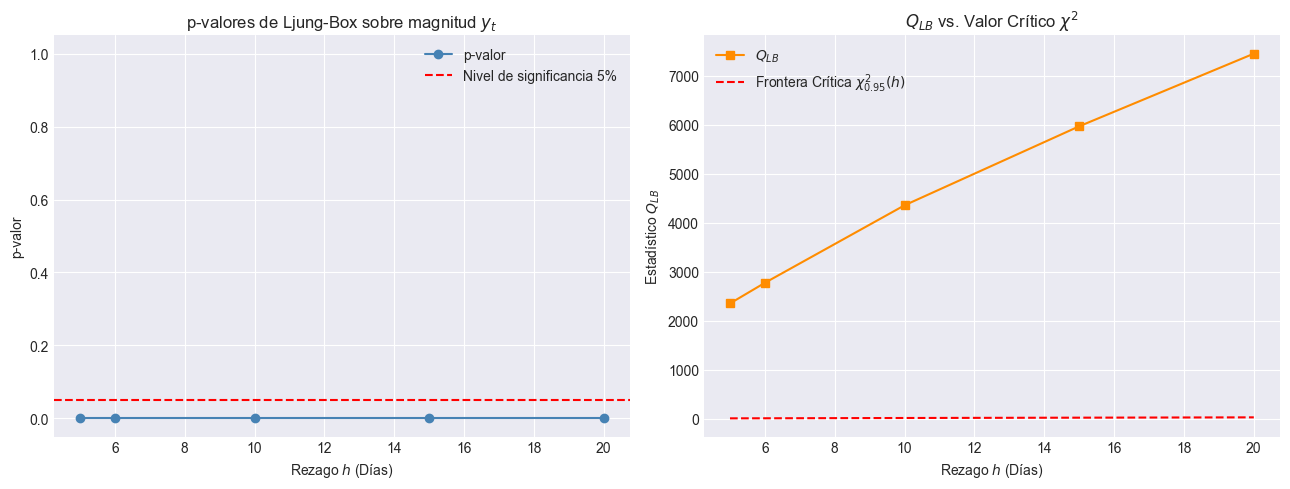

In [84]:
from statsmodels.stats.diagnostic import acorr_ljungbox

n = len(ts)
lags_lb = sorted(set([5, 10, 15, 20, int(np.log(n))]))

# Ejecución de la prueba de Ljung-Box
lb_result = acorr_ljungbox(ts.dropna(), lags=lags_lb, return_df=True)

print("Prueba de Ljung-Box sobre la Magnitud Diaria (y_t)")
print("=" * 65)
print(f"{'Rezago h':>10} {'Estadístico Q':>15} {'p-valor':>15} {'Conclusión':>20}")
print("-" * 65)

for index, row in lb_result.iterrows():
    q  = float(row['lb_stat'])
    p  = float(row['lb_pvalue'])
    c  = 'Rechaza H0 (Hay autocorrelación)' if p < 0.05 else 'No rechaza H0 (Ruido Blanco)'
    print(f"{int(index):>10} {q:>15.4f} {p:>15.6f} {c:>20}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Gráfica de p-valores
axes[0].plot(lb_result.index, lb_result['lb_pvalue'].astype(float),
             'o-', color='steelblue', label='p-valor')
axes[0].axhline(0.05, color='red', linestyle='--', label='Nivel de significancia 5%')
axes[0].set_xlabel('Rezago $h$ (Días)')
axes[0].set_ylabel('p-valor')
axes[0].set_title('p-valores de Ljung-Box sobre magnitud $y_t$')
axes[0].set_ylim([-0.05, 1.05])
axes[0].legend()

# Panel 2: Estadístico Q vs. Valor Crítico Chi-Cuadrada
axes[1].plot(lb_result.index, lb_result['lb_stat'].astype(float),
             's-', color='darkorange', label='$Q_{LB}$')


chi2_crit = [stats.chi2.ppf(0.95, df=int(h)) for h in lb_result.index]
axes[1].plot(lb_result.index, chi2_crit, 'r--', label='Frontera Crítica $\\chi^2_{0.95}(h)$')

axes[1].set_xlabel('Rezago $h$ (Días)')
axes[1].set_ylabel('Estadístico $Q_{LB}$')
axes[1].set_title('$Q_{LB}$ vs. Valor Crítico $\\chi^2$')
axes[1].legend()

plt.tight_layout()
plt.show()

In [85]:
ts_clean = ts.dropna()
n_obs = len(ts_clean)
acf_vals = acf(ts_clean, nlags=5)

rho_hat_1 = acf_vals[1] 

# Cálculo matemático del estadístico Q_LB para h=1
qlb_1 = n_obs * (n_obs + 2) * (rho_hat_1**2) / (n_obs - 1)

print("--- Desglose Matemático: Prueba de Ljung-Box (h=1) ---")
print(f"Número de observaciones (n): {n_obs}")
print(f"ACF estimada en rezago 1 (ρ̂(1)): {rho_hat_1:.4f}")
print(f"\nCálculo exacto de Q_LB para h=1:")
print(f"  {n_obs} * ({n_obs} + 2) * ({rho_hat_1:.4f}^2) / ({n_obs} - 1)")
print(f"  = {n_obs * (n_obs + 2)} * {rho_hat_1**2:.6f} / {n_obs - 1}")
print(f"  = {qlb_1:.4f}\n")

# Para comparar, el p-valor para una distribución chi-cuadrada con 1 grado de libertad
p_val_1 = 1 - stats.chi2.cdf(qlb_1, df=1)

print("Resultado y Conclusión")
print(f"Estadístico Q_LB(1(: {qlb_1:.4f}")
print(f"p-valor asociado: {p_val_1:.6f}")

if p_val_1 < 0.05:
    print("Conclusión a h=1: Rechaza H0 (Hay dependencia del día inmediatamente anterior)")
else:
    print("Conclusión a h=1: No rechaza H0 (El rezago 1 es estadísticamente igual a cero)")

--- Desglose Matemático: Prueba de Ljung-Box (h=1) ---
Número de observaciones (n): 731
ACF estimada en rezago 1 (ρ̂(1)): 0.8745

Cálculo exacto de Q_LB para h=1:
  731 * (731 + 2) * (0.8745^2) / (731 - 1)
  = 535823 * 0.764712 / 730
  = 561.3018

Resultado y Conclusión
Estadístico Q_LB(1(: 561.3018
p-valor asociado: 0.000000
Conclusión a h=1: Rechaza H0 (Hay dependencia del día inmediatamente anterior)


In [86]:
ts_clean = ts.dropna()
n_obs = len(ts_clean)

# Calculamos la ACF hasta 20 rezagos para que la función no falle
acf_vals = acf(ts_clean, nlags=20)

def calculate_qlb_detailed(n_obs, acf_values, h_lags):
    """Calcula y desglosa paso a paso el estadístico de Ljung-Box."""
    
    print(f"\n{'='*65}")
    print(f"--- Cálculo Detallado de Q_LB para h = {h_lags} rezagos ---")
    print(f"{'='*65}")
    print(f"Número de observaciones (n): {n_obs}")

    sum_terms = 0.0
    print("\n  Desglose de la Sumatoria de términos Σ [ ρ̂(k)^2 / (n-k) ] :")
    
    # Iteramos desde el rezago 1 hasta h_lags
    for k in range(1, h_lags + 1):
        rho_k_squared = acf_values[k] ** 2
        term = rho_k_squared / (n_obs - k)
        sum_terms += term
        # Mostramos 8 decimales al final para no perder precisión visual
        print(f"    k={k:<2}: ρ̂({k:<2})^2 = {rho_k_squared:.6f} / ({n_obs}-{k}) = {term:.8f}")

    # Fórmula principal de Ljung-Box
    qlb_statistic = n_obs * (n_obs + 2) * sum_terms
    # Cálculo del p-valor usando Chi-Cuadrada
    p_value = 1 - stats.chi2.cdf(qlb_statistic, df=h_lags)

    print(f"\n  Resultados Finales:")
    print(f"  Suma total de términos (Σ) : {sum_terms:.8f}")
    print(f"  Factor constante n(n+2)    : {n_obs} * ({n_obs} + 2) = {n_obs * (n_obs + 2)}")
    print(f"  Estadístico Q_LB({h_lags})    : {n_obs * (n_obs + 2)} * {sum_terms:.8f} = {qlb_statistic:.4f}")
    print(f"  p-valor (df={h_lags})         : {p_value:.6f}")
    
    if p_value < 0.05:
         print(f"  Conclusión                 : Rechaza H0 (Hay autocorrelación conjunta hasta {h_lags} días)")
    else:
         print(f"  Conclusión                 : No rechaza H0 (Ruido Blanco, NO hay autocorrelación conjunta)")

# Aplicar para h = 15 rezagos
calculate_qlb_detailed(n_obs, acf_vals, 15)

# Aplicar para h = 20 rezagos
calculate_qlb_detailed(n_obs, acf_vals, 20)


--- Cálculo Detallado de Q_LB para h = 15 rezagos ---
Número de observaciones (n): 731

  Desglose de la Sumatoria de términos Σ [ ρ̂(k)^2 / (n-k) ] :
    k=1 : ρ̂(1 )^2 = 0.764712 / (731-1) = 0.00104755
    k=2 : ρ̂(2 )^2 = 0.665445 / (731-2) = 0.00091282
    k=3 : ρ̂(3 )^2 = 0.604539 / (731-3) = 0.00083041
    k=4 : ρ̂(4 )^2 = 0.581661 / (731-4) = 0.00080008
    k=5 : ρ̂(5 )^2 = 0.582719 / (731-5) = 0.00080264
    k=6 : ρ̂(6 )^2 = 0.569297 / (731-6) = 0.00078524
    k=7 : ρ̂(7 )^2 = 0.578847 / (731-7) = 0.00079951
    k=8 : ρ̂(8 )^2 = 0.550317 / (731-8) = 0.00076116
    k=9 : ρ̂(9 )^2 = 0.516342 / (731-9) = 0.00071516
    k=10: ρ̂(10)^2 = 0.486439 / (731-10) = 0.00067467
    k=11: ρ̂(11)^2 = 0.456919 / (731-11) = 0.00063461
    k=12: ρ̂(12)^2 = 0.443754 / (731-12) = 0.00061718
    k=13: ρ̂(13)^2 = 0.429771 / (731-13) = 0.00059857
    k=14: ρ̂(14)^2 = 0.424870 / (731-14) = 0.00059257
    k=15: ρ̂(15)^2 = 0.402724 / (731-15) = 0.00056246

  Resultados Finales:
  Suma total de términos

## Estimación del modelo de la media condicional

Estimación AR(1) — Componente determinista de Sismos
  Constante (μ) : 0.4000
  ϕ estimado    : 0.8745
  AIC           : -420.1088
  BIC           : -406.3297
  Obs. usadas   : 730

Ljung-Box sobre residuos ε̂_t (¿Ruido blanco en la media?)
-------------------------------------------------------
  Rezago h         Q_LB      p-valor             Conclusión
-------------------------------------------------------
         5      33.3456     0.000003     Autocorr. residual
         6      33.3600     0.000009     Autocorr. residual
        10      54.7289     0.000000     Autocorr. residual
        15      65.2774     0.000000     Autocorr. residual
        20      84.3008     0.000000     Autocorr. residual


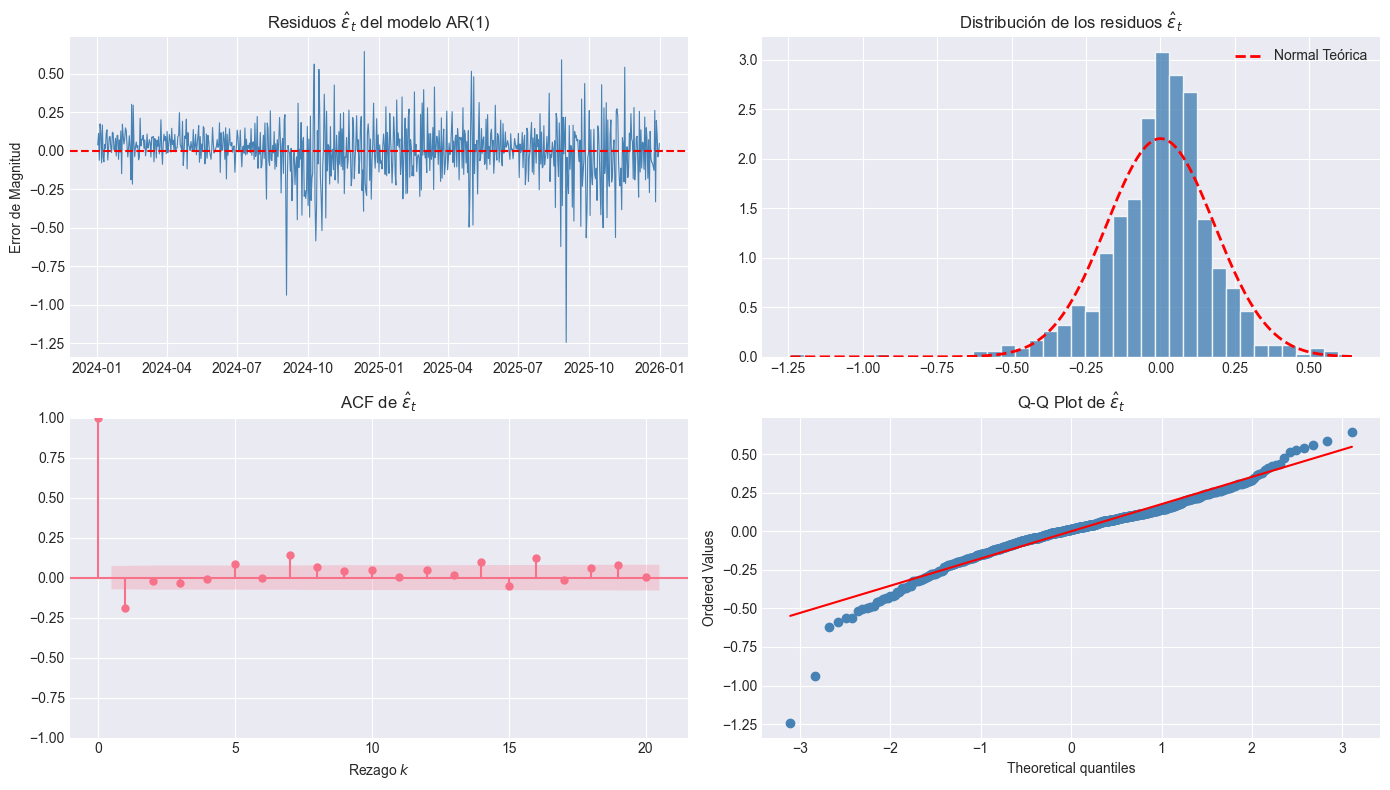


Test Jarque-Bera sobre residuos:
  Estadístico = 727.0395  |  p-valor = 0.0000
  Curtosis = 4.6596 (Exceso)  |  Asimetría = -0.8020
  Conclusión: Se rechaza normalidad (Colas pesadas — Fuerte indicio de Efecto ARCH)


In [87]:
import scipy.stats as stats
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# 1. ESTIMACIÓN DEL MODELO AR(1)
ts_clean = ts.dropna()

# Estimación AR(1) por Mínimos Cuadrados Ordinarios (OLS)
modelo_ar1 = AutoReg(ts_clean, lags=1, trend='c').fit()

constante = modelo_ar1.params.iloc[0]
phi_hat   = modelo_ar1.params.iloc[1]
residuos  = modelo_ar1.resid

print("Estimación AR(1) — Componente determinista de Sismos")
print("=" * 55)
print(f"  Constante (μ) : {constante:.4f}")
print(f"  ϕ estimado    : {phi_hat:.4f}")
print(f"  AIC           : {modelo_ar1.aic:.4f}")
print(f"  BIC           : {modelo_ar1.bic:.4f}")
print(f"  Obs. usadas   : {modelo_ar1.nobs:.0f}")

n = len(ts_clean)
lags_lb = sorted(set([5, 10, 15, 20, int(np.log(n))]))

lb_resid = acorr_ljungbox(residuos, lags=lags_lb, return_df=True)

print("\nLjung-Box sobre residuos ε̂_t (¿Ruido blanco en la media?)")
print("-" * 55)
print(f"{'Rezago h':>10} {'Q_LB':>12} {'p-valor':>12} {'Conclusión':>22}")
print("-" * 55)
for index, row in lb_resid.iterrows():
    q = float(row['lb_stat'])
    p = float(row['lb_pvalue'])
    c = 'Autocorr. residual' if p < 0.05 else 'Sin autocorr. (OK)'
    print(f"{int(index):>10} {q:>12.4f} {p:>12.6f} {c:>22}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(residuos.index, residuos, color='steelblue', linewidth=0.8)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,0].set_title('Residuos $\\hat{\\varepsilon}_t$ del modelo AR(1)')
axes[0,0].set_ylabel('Error de Magnitud')

axes[0,1].hist(residuos, bins=40, color='steelblue', edgecolor='white', alpha=0.8, density=True)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0,1].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()), 
               'r--', linewidth=2, label='Normal Teórica')
axes[0,1].set_title('Distribución de los residuos $\\hat{\\varepsilon}_t$')
axes[0,1].legend()

# Panel Abajo-Izquierda: ACF de los residuos
plot_acf(residuos, lags=20, ax=axes[1,0], title='ACF de $\\hat{\\varepsilon}_t$')
axes[1,0].set_xlabel('Rezago $k$')

# Panel Abajo-Derecha: Q-Q Plot
stats.probplot(residuos, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot de $\\hat{\\varepsilon}_t$')
axes[1,1].get_lines()[0].set_markerfacecolor('steelblue')
axes[1,1].get_lines()[0].set_markeredgecolor('steelblue')

plt.tight_layout()
plt.show()

# 4. TEST DE NORMALIDAD (Jarque-Bera)
stat_jb, p_jb = stats.jarque_bera(residuos)
print(f"\nTest Jarque-Bera sobre residuos:")
print(f"  Estadístico = {stat_jb:.4f}  |  p-valor = {p_jb:.4f}")
print(f"  Curtosis = {residuos.kurtosis():.4f} (Exceso)  |  Asimetría = {residuos.skew():.4f}")

if p_jb < 0.05:
    print("  Conclusión: Se rechaza normalidad (Colas pesadas — Fuerte indicio de Efecto ARCH)")
else:
    print("  Conclusión: No se rechaza normalidad")

# BLOQUE C

## Inspección Visual del Componente Aleatorio 

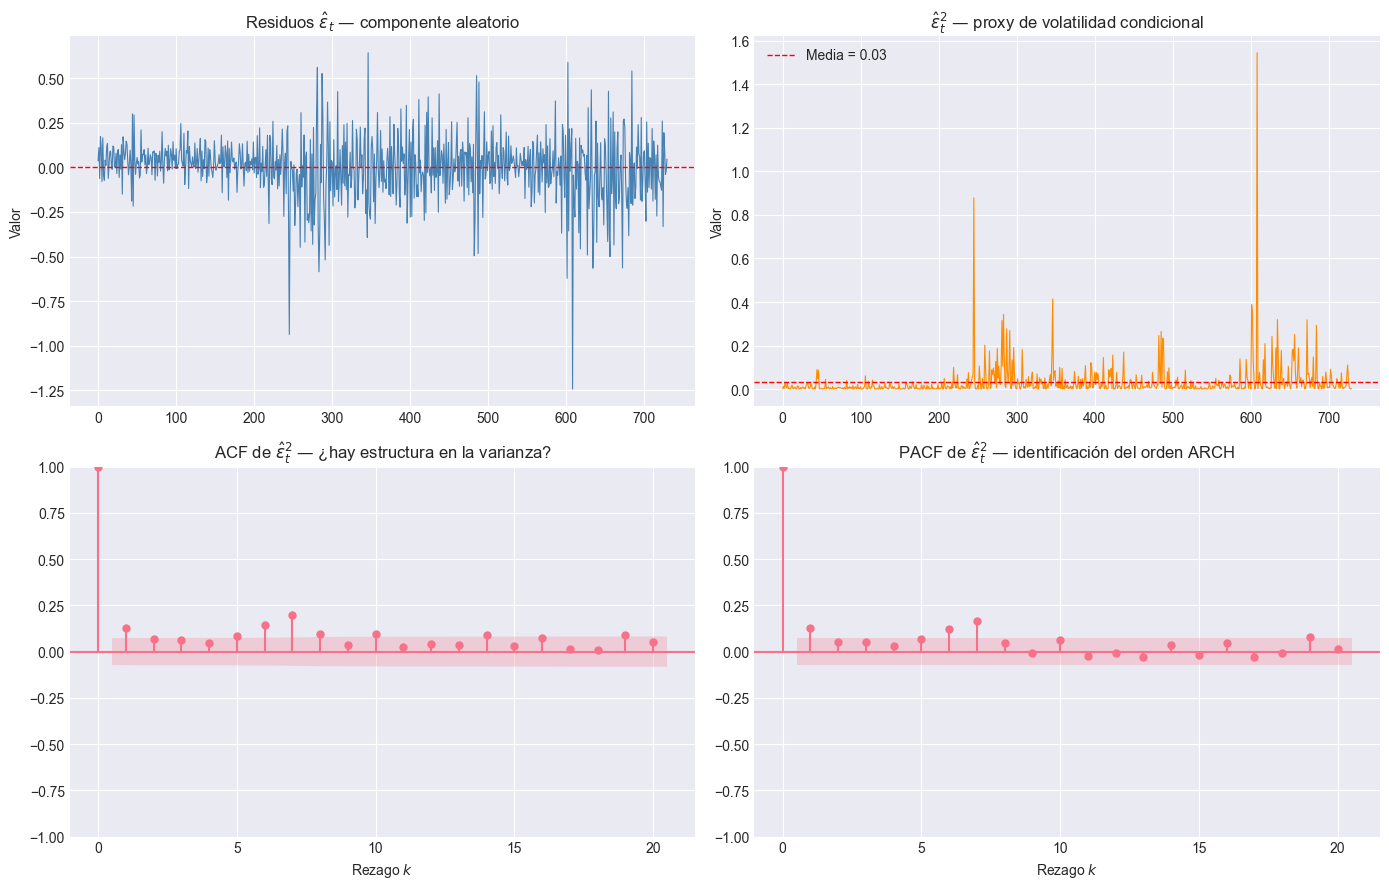

Estadísticos del componente aleatorio:
  Media de ε̂_t        : 0.0000  (esperado: ~0)
  Varianza de ε̂_t     : 0.0327
  Curtosis en exceso  : 4.6596  (normal = 0; > 0 indica colas pesadas)


In [88]:
resid2 = residuos ** 2

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Residuos en nivel
axes[0,0].plot(residuos.values, color='steelblue', linewidth=0.8)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,0].set_title('Residuos $\\hat{\\varepsilon}_t$ — componente aleatorio')
axes[0,0].set_ylabel('Valor')

# Residuos al cuadrado
axes[0,1].plot(resid2.values, color='darkorange', linewidth=0.8)
axes[0,1].axhline(resid2.mean(), color='red', linestyle='--', linewidth=1,
                  label=f'Media = {resid2.mean():.2f}')
axes[0,1].set_title('$\\hat{\\varepsilon}_t^2$ — proxy de volatilidad condicional')
axes[0,1].set_ylabel('Valor')
axes[0,1].legend()

# ACF de residuos al cuadrado
plot_acf(resid2, lags=20, ax=axes[1,0],
         title='ACF de $\\hat{\\varepsilon}_t^2$ — ¿hay estructura en la varianza?')
axes[1,0].set_xlabel('Rezago $k$')

# PACF de residuos al cuadrado
plot_pacf(resid2, lags=20, ax=axes[1,1], method='ywm',
          title='PACF de $\\hat{\\varepsilon}_t^2$ — identificación del orden ARCH')
axes[1,1].set_xlabel('Rezago $k$')

plt.tight_layout()
plt.show()

print("Estadísticos del componente aleatorio:")
print(f"  Media de ε̂_t        : {residuos.mean():.4f}  (esperado: ~0)")
print(f"  Varianza de ε̂_t     : {residuos.var():.4f}")
print(f"  Curtosis en exceso  : {residuos.kurt():.4f}  (normal = 0; > 0 indica colas pesadas)")

## Prueba de Ljung - Box

Ljung-Box sobre $\hat{\varepsilon}_t^2$ — ¿estructura en la varianza?
  Rezago h         Q_LB      p-valor             Conclusión
-------------------------------------------------------
         5      25.3012     0.000122      Rechaza H0 (ARCH)
         6      40.8164     0.000000      Rechaza H0 (ARCH)
        10      84.7895     0.000000      Rechaza H0 (ARCH)
        15      93.9569     0.000000      Rechaza H0 (ARCH)
        20     106.2498     0.000000      Rechaza H0 (ARCH)


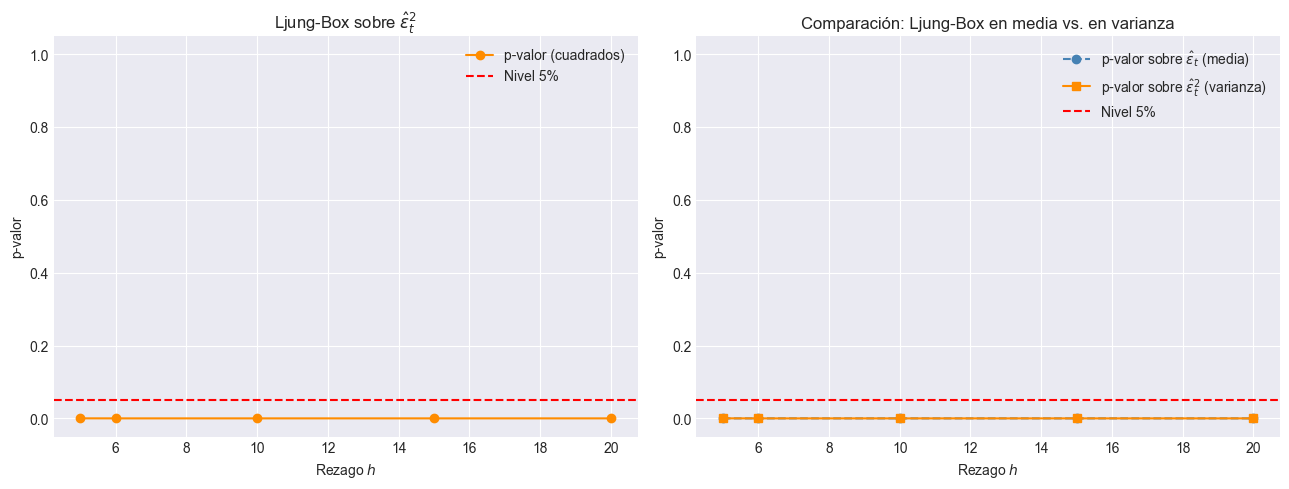

In [89]:
lb_u2 = acorr_ljungbox(resid2, lags=lags_lb, return_df=True)

print("Ljung-Box sobre $\\hat{\\varepsilon}_t^2$ — ¿estructura en la varianza?")
print("=" * 55)
print(f"{'Rezago h':>10} {'Q_LB':>12} {'p-valor':>12} {'Conclusión':>22}")
print("-" * 55)
for _, row in lb_u2.iterrows():
    q = float(row['lb_stat'])
    p = float(row['lb_pvalue'])
    c = 'Rechaza H0 (ARCH)' if p < 0.05 else 'No rechaza H0'
    print(f"{int(row.name):>10} {q:>12.4f} {p:>12.6f} {c:>22}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(lb_u2.index, lb_u2['lb_pvalue'].astype(float),
             'o-', color='darkorange', label='p-valor (cuadrados)')
axes[0].axhline(0.05, color='red', linestyle='--', label='Nivel 5%')
axes[0].set_xlabel('Rezago $h$')
axes[0].set_ylabel('p-valor')
axes[0].set_title('Ljung-Box sobre $\\hat{\\varepsilon}_t^2$')
axes[0].set_ylim([-0.05, 1.05])
axes[0].legend()

# Comparación: p-valores sobre ε̂_t vs ε̂_t²
lb_u_orig = acorr_ljungbox(residuos, lags=lags_lb, return_df=True)
axes[1].plot(lb_u_orig.index, lb_u_orig['lb_pvalue'].astype(float),
             'o--', color='steelblue', label='p-valor sobre $\\hat{\\varepsilon}_t$ (media)')
axes[1].plot(lb_u2.index, lb_u2['lb_pvalue'].astype(float),
             's-', color='darkorange', label='p-valor sobre $\\hat{\\varepsilon}_t^2$ (varianza)')
axes[1].axhline(0.05, color='red', linestyle='--', label='Nivel 5%')
axes[1].set_xlabel('Rezago $h$')
axes[1].set_ylabel('p-valor')
axes[1].set_title('Comparación: Ljung-Box en media vs. en varianza')
axes[1].set_ylim([-0.05, 1.05])
axes[1].legend()

plt.tight_layout()
plt.show()

## Prueba ARCH-LM

In [90]:
# PRUEBA ARCH-LM DE ENGLE
import numpy as np
import scipy.stats as stats

def arch_lm_test(series, lags=1):
    """Prueba ARCH-LM: H0 = no hay efectos ARCH(q)"""
    
    x2 = series.values ** 2
    n_obs = len(x2)

    # Variable dependiente
    y_reg = x2[lags:]

    # Matriz de regresores (rezagos de u_t^2)
    X_reg = np.column_stack([
        x2[lags - j : n_obs - j] for j in range(1, lags + 1)
    ])

    # Agregar constante
    X_reg = np.hstack([np.ones((len(y_reg), 1)), X_reg])

    # Estimación OLS
    beta = np.linalg.lstsq(X_reg, y_reg, rcond=None)[0]

    # Residuos de la regresión auxiliar
    resid = y_reg - X_reg @ beta

    # Cálculo de R²
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((y_reg - y_reg.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    # Estadístico LM
    lm = len(y_reg) * r2

    # p-valor (Chi-cuadrada)
    p_val = 1 - stats.chi2.cdf(lm, df=lags)

    return lm, p_val, r2, beta[1:]


# RESULTADOS PARA VARIOS ÓRDENES q
print("Prueba ARCH-LM — Componente aleatorio")
print("=" * 65)
print(f"{'Orden q':>10} {'LM stat':>12} {'p-valor':>12} {'R²':>10} {'Conclusión':>20}")
print("-" * 65)

for q in [1, 2, 3, 5]:
    lm, pv, r2, coefs = arch_lm_test(residuos, lags=q)
    conclusion = 'ARCH detectado' if pv < 0.05 else 'No rechaza H0'
    print(f"{q:>10} {lm:>12.4f} {pv:>12.6f} {r2:>10.4f} {conclusion:>20}")


# DETALLE PARA ARCH(1)
lm1, pv1, r2_1, coefs1 = arch_lm_test(residuos, lags=1)

print("\nDetalle ARCH-LM(1):")
print(f"  γ₁ estimado: {coefs1[0]:.4f}")
print(f"  R²         : {r2_1:.4f}")
print(f"  Interpretación: {r2_1*100:.2f}% de la varianza de ε̂_t² se explica por ε̂_(t-1)²")

Prueba ARCH-LM — Componente aleatorio
   Orden q      LM stat      p-valor         R²           Conclusión
-----------------------------------------------------------------
         1      11.5442     0.000680     0.0158       ARCH detectado
         2      13.6394     0.001092     0.0187       ARCH detectado
         3      15.4678     0.001458     0.0213       ARCH detectado
         5      19.6330     0.001464     0.0271       ARCH detectado

Detalle ARCH-LM(1):
  γ₁ estimado: 0.1258
  R²         : 0.0158
  Interpretación: 1.58% de la varianza de ε̂_t² se explica por ε̂_(t-1)²


## Estimación del modelo de volatilidad

Estimación ARCH(1) — Componente de volatilidad
  α₀ estimado : 0.028588
  α₁ estimado : 0.125839
  α₁ < 1      : True  (condición de estacionariedad)
  Varianza incondicional estimada: 0.032704


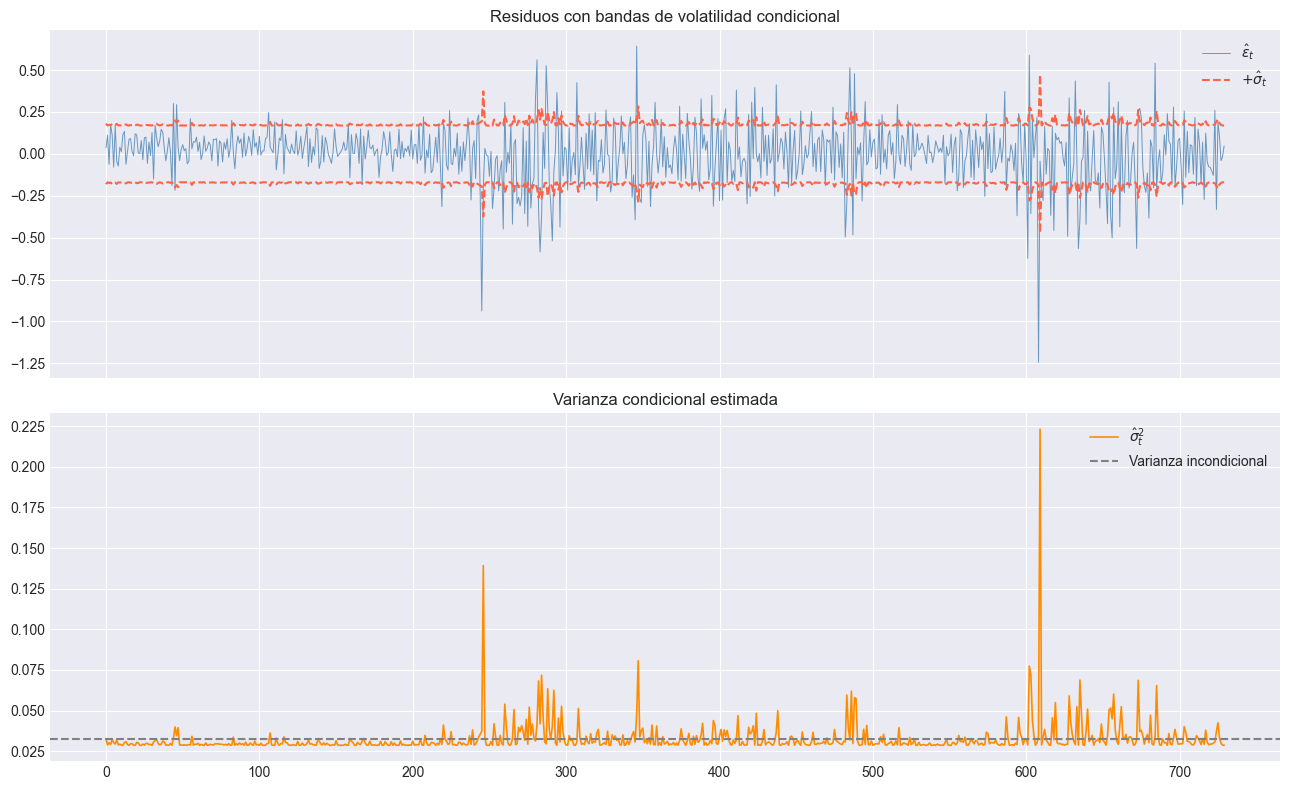

In [91]:
# ESTIMACIÓN DEL MODELO ARCH(1) POR OLS

# Cuadrados de residuos
u2_vals = residuos.values ** 2

# Variable dependiente (desde t=2)
y_arch = u2_vals[1:]

# Regresores: constante + rezago de u_t^2
X_arch = np.column_stack([
    np.ones(len(y_arch)),
    u2_vals[:-1]
])

# Estimación OLS
beta_arch = np.linalg.lstsq(X_arch, y_arch, rcond=None)[0]
alpha0_hat, alpha1_hat = beta_arch

print("Estimación ARCH(1) — Componente de volatilidad")
print("=" * 55)
print(f"  α₀ estimado : {alpha0_hat:.6f}")
print(f"  α₁ estimado : {alpha1_hat:.6f}")
print(f"  α₁ < 1      : {alpha1_hat < 1}  (condición de estacionariedad)")


# VARIANZA INCONDICIONAL
var_eps_hat = alpha0_hat / (1 - alpha1_hat)
print(f"  Varianza incondicional estimada: {var_eps_hat:.6f}")


# VARIANZA CONDICIONAL σ²_t
sigma2_hat = np.zeros(len(residuos))
sigma2_hat[0] = residuos.var()

for t in range(1, len(residuos)):
    sigma2_hat[t] = alpha0_hat + alpha1_hat * (residuos.values[t-1] ** 2)




fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)


axes[0].plot(residuos.values, color='steelblue', linewidth=0.7, alpha=0.8,
             label='$\\hat{\\varepsilon}_t$')

axes[0].plot(np.sqrt(sigma2_hat), color='tomato', linestyle='--', linewidth=1.5,
             label='$+\\hat{\\sigma}_t$')

axes[0].plot(-np.sqrt(sigma2_hat), color='tomato', linestyle='--', linewidth=1.5)

axes[0].set_title('Residuos con bandas de volatilidad condicional')
axes[0].legend()


# Varianza condicional
axes[1].plot(sigma2_hat, color='darkorange', linewidth=1.2,
             label='$\\hat{\\sigma}_t^2$')

axes[1].axhline(var_eps_hat, color='gray', linestyle='--',
                label='Varianza incondicional')

axes[1].set_title('Varianza condicional estimada')
axes[1].legend()

plt.tight_layout()
plt.show()

Estimación ARCH(1) — Modelo de volatilidad
  α₀ estimado : 0.028588
  α₁ estimado : 0.125839
  α₁ < 1      : True (condición de estacionariedad)
  Varianza incondicional: 0.032704


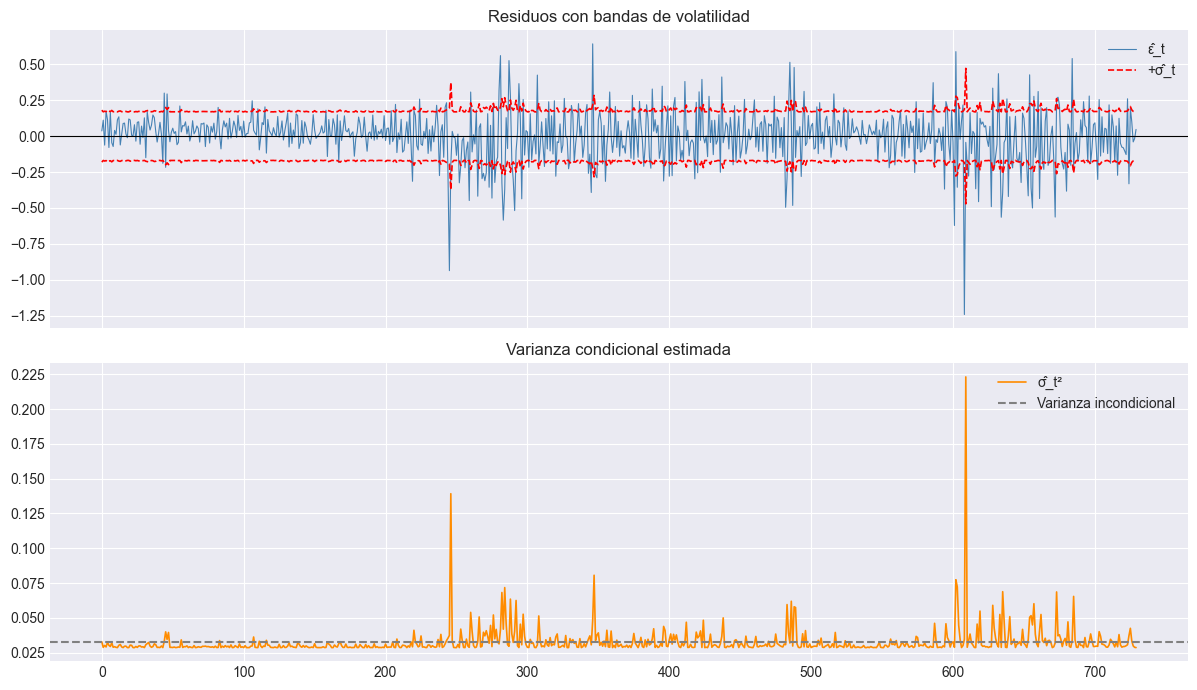

In [92]:
# Cuadrados de los residuos
u2_vals = residuos.values ** 2

# Variable dependiente (u_t^2 desde t=2)
y_arch = u2_vals[1:]

# Matriz de regresores: constante + u_(t-1)^2
X_arch = np.column_stack([
    np.ones(len(y_arch)),
    u2_vals[:-1]
])

# Estimación por MCO
beta_arch = np.linalg.lstsq(X_arch, y_arch, rcond=None)[0]
alpha0_hat, alpha1_hat = beta_arch

# Resultados
print("Estimación ARCH(1) — Modelo de volatilidad")
print("=" * 50)
print(f"  α₀ estimado : {alpha0_hat:.6f}")
print(f"  α₁ estimado : {alpha1_hat:.6f}")
print(f"  α₁ < 1      : {alpha1_hat < 1} (condición de estacionariedad)")

# Varianza incondicional
var_eps_hat = alpha0_hat / (1 - alpha1_hat)
print(f"  Varianza incondicional: {var_eps_hat:.6f}")

# Construcción de la varianza condicional σ²_t
sigma2_hat = np.zeros(len(residuos))
sigma2_hat[0] = residuos.var()

for t in range(1, len(residuos)):
    sigma2_hat[t] = alpha0_hat + alpha1_hat * (residuos.values[t-1] ** 2)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(residuos.values, color='steelblue', lw=0.8, label='ε̂_t')
axes[0].plot(np.sqrt(sigma2_hat), 'r--', lw=1.2, label='+σ̂_t')
axes[0].plot(-np.sqrt(sigma2_hat), 'r--', lw=1.2)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Residuos con bandas de volatilidad')
axes[0].legend()

# Varianza condicional
axes[1].plot(sigma2_hat, color='darkorange', lw=1.2, label='σ̂_t²')
axes[1].axhline(var_eps_hat, color='gray', linestyle='--',
                label='Varianza incondicional')
axes[1].set_title('Varianza condicional estimada')
axes[1].legend()

plt.tight_layout()
plt.show()